In [32]:
# config file paths
import os

EVENTS_CSV_PATH = os.path.join(
    "x-rays E = 1.0keV for filtering",
    "filtered_before_erass2_overlap_regions_and_observation_time_>=0.1_scattering_probability_and_<=0.950212931632136_absorption_probability.csv",
)
BOUNDARY_DIR = os.path.join(
    "x-rays E = 1.0keV for filtering",
    "overlap_boundaries",
)

print("EVENTS_CSV_PATH exists:", os.path.exists(EVENTS_CSV_PATH))
print("BOUNDARY_DIR exists:", os.path.exists(BOUNDARY_DIR))

EVENTS_CSV_PATH exists: True
BOUNDARY_DIR exists: True


In [33]:
# Step 1: Boundary polygon -> covering eROSITA skytiles

"""
The GW boundary polygons span tens of degrees. Lay down a grid of sample points across the
polygon's bounding box, query the skytile API at each point, and
collect the unique set of skytiles that come back.

"""

import csv
import time
import requests
import numpy as np


def load_boundary_polygon(boundary_json_path):
    blobs = {}
    with open(boundary_json_path, "r") as f:
        reader = csv.DictReader(f)
        for row in reader:
            blob_id = int(row["blob_id"])
            ra = float(row["ra"])
            dec = float(row["dec"])
            blobs.setdefault(blob_id, []).append((ra, dec))
    return blobs


def point_in_polygon(ra, dec, polygon_ra, polygon_dec):
    # ra, dec is some point
    # polygon_ra, polygon_dec are points on the boundaries
    n = len(polygon_ra) # number of points
    inside = False
    j = n - 1 # last index
    for i in range(n):
        # get next edge
        xi, yi = polygon_ra[i], polygon_dec[i] # vertex 1
        xj, yj = polygon_ra[j], polygon_dec[j] #vertex 2
        if ((yi > dec) != (yj > dec)) and (
            ra < (xj - xi) * (dec - yi) / (yj - yi + 1e-15) + xi
        ): 
            # point must be vertically (dec) wihtin the vertices, 
            # (xj - xi) * (dec - yi) / (yj - yi + 1e-15) + xi is the ra coord where edge hits dec
            # ra < ... tests if point is to the left of the edge
            inside = not inside # counts crossing from left to right. Odd number means point is inside
        j = i # test every edge
    return inside


def sample_grid_inside_polygon(polygon_ra, polygon_dec, step_deg=1.5):
    """
    Lay a regular grid over the polygon's bounding box at `step_deg`
    spacing, keep only the points (grid intersections) that fall inside the polygon. 
    This is to figure out which skytiles we should use.

    step_deg should be smaller than the skytile size (3.6 deg) so we
    don't skip over a tile - 1.5 deg gives good coverage with margin.
    """
    ra_arr = np.array(polygon_ra)
    dec_arr = np.array(polygon_dec)

    ra_grid = np.arange(ra_arr.min(), ra_arr.max() + step_deg, step_deg)
    dec_grid = np.arange(dec_arr.min(), dec_arr.max() + step_deg, step_deg)

    points = []
    for ra in ra_grid:
        for dec in dec_grid:
            if point_in_polygon(ra, dec, polygon_ra, polygon_dec):
                points.append((ra, dec))
    return points

def find_skytiles_at_point(ra_icrs, dec_icrs, search_radius_deg=0.1):
    """
    Calls the eROSITA skytile search API for a single sky position.

    IMPORTANT: ra_icrs/dec_icrs must be equatorial (ICRS) coordinates
    in decimal degrees - the API's RA/DEC parameters are documented
    with a plain equatorial example (RA=180&DEC=-45) and there is no
    coordinate-system parameter, unlike the *manual* skytile search
    web form (which has an ICRS/FK5/Galactic/Ecliptic/FK4 dropdown -
    that dropdown applies to the web UI only, not this API).

    Our boundary JSON files provide both ra/dec (equatorial) and l/b
    (galactic) per vertex - load_boundary_polygon() already reads the
    ra/dec columns, so values flowing into this function are correct
    as long as you don't substitute l/b in by mistake upstream.
    """
    url = (
        "https://erosita.mpe.mpg.de/dr1/erodat/skyview/skytile_search_api/"
        f"?RA={ra_icrs}&DEC={dec_icrs}&RAD={search_radius_deg}"
    )

    # Transient server errors (502/503/504, or connection drops) are
    # common when hammering this API with many calls in a row (one
    # per grid-sample point across a boundary polygon). These usually
    # succeed on retry a moment later, unlike a genuine 404 (missing
    # resource) which won't change no matter how many times you ask.
    # A short retry-with-backoff avoids one transient hiccup aborting
    # the entire multi-event search.
    max_retries = 3
    for attempt in range(max_retries):
        try:
            resp = requests.get(url, timeout=30)
            resp.raise_for_status()
            return resp.json().get("tiles", [])
        except requests.exceptions.RequestException as e:
            if attempt < max_retries - 1:
                wait_s = 2 ** attempt  # 1s, 2s, 4s
                print(f"    [retry] skytile search at RA={ra_icrs:.4f} DEC={dec_icrs:.4f} "
                      f"failed ({e}), retrying in {wait_s}s...")
                time.sleep(wait_s)
            else:
                print(f"    [fail] skytile search at RA={ra_icrs:.4f} DEC={dec_icrs:.4f} "
                      f"failed after {max_retries} attempts ({e}) - skipping this sample point")
                return []

def find_all_skytiles_for_blob(polygon_ra, polygon_dec, step_deg=1.5):
    """
    Full procedure: grid-sample the polygon, query each sample point,
    de-duplicate by srvmap tile number.
    """
    sample_points = sample_grid_inside_polygon(polygon_ra, polygon_dec, step_deg)
    seen_tiles = {}  # survey map -> tile info dict

    for ra, dec in sample_points:
        tiles = find_skytiles_at_point(ra, dec)
        for t in tiles:
            seen_tiles[t["srvmap"]] = t # t["srvmap"] gets the unique 6-digit eROSITA Tile ID

    return list(seen_tiles.values()), sample_points


def find_all_skytiles_for_event(boundary_json_path, step_deg=1.5):
    """
    Like find_all_skytiles_for_blob, but covers every blob in the
    boundary file (the main patch plus any small disjoint fragments),
    de-duplicated across all of them. This is what you want for "one
    search per event" - the search region is the union of every blob.
    """
    blobs = load_boundary_polygon(boundary_json_path)
    seen_tiles = {}
    all_samples = []

    for blob_id, points in blobs.items():
        ra_list = [p[0] for p in points]
        dec_list = [p[1] for p in points]

        if len(points) < 3:
            # Degenerate blob (1-2 points) - can't form a polygon.
            # Treat the point(s) themselves as the sample(s).
            samples = points
        else:
            samples = sample_grid_inside_polygon(ra_list, dec_list, step_deg)
            if not samples:
                # blob is smaller than step_deg in both directions -
                # grid sampling found nothing inside; fall back to
                # using its vertices directly so it's not dropped.
                samples = points

        all_samples.extend(samples)
        for ra, dec in samples:
            tiles = find_skytiles_at_point(ra, dec)
            for t in tiles:
                seen_tiles[t["srvmap"]] = t

    return list(seen_tiles.values()), all_samples, blobs


In [34]:
# Step 2: theta(dt) radius window, crop, edge-detect, circular Hough transform

"""
Step 2/3: given a skytile srvmap number, download its FITS image,
mask to the GW boundary polygon's footprint, and run a circular
Hough transform whose search radius is derived per-observation from
the dust-echo physics: theta proportional to sqrt(delta_t).

Image scale (from eROSITA DR1 docs): 3240x3240 px covering 3.6x3.6 deg
  -> 4 arcsec/pixel

Dust-echo radius-time relation:
  delta_t ~ theta^2 / 2   (the proportionality constant folds in dust
  distance and geometry, which we don't know exactly per-source - so
  we calibrate it from the one data point we were given: theta=30
  arcmin at delta_t=365 days, i.e. theta(dt) = 30 * sqrt(dt_days/365)).

Because that calibration point itself has real uncertainty (unknown
dust-sheet distance, departure from the small-angle approximation,
etc.), we don't search a single radius - we search a band around the
predicted theta, controlled by RADIUS_UNCERTAINTY_FRAC below.
"""

import io
import re
import requests
import numpy as np
from astropy.io import fits
from astropy.wcs import WCS

ARCSEC_PER_PIXEL = 4.0

# Calibration point you were given: 1 year -> 30 arcmin
REF_DT_DAYS = 365.0
REF_THETA_ARCMIN = 30.0

# How much slack to put around the predicted theta, since the
# proportionality constant isn't known precisely. +-20% is a
# reasonable starting point; tighten it if you trust the calibration
# more, widen it if candidates are coming up empty.
RADIUS_UNCERTAINTY_FRAC = 0.20


def parse_relative_time_to_days(time_str):
    """
    Parses the CSV's 'time_relative_to_gw_detection' format, e.g.
    '+122d 11h 26m 1.9s' -> 122.476... (float days)
    """
    m = re.match(r"\+?(\d+)d\s+(\d+)h\s+(\d+)m\s+([\d.]+)s", time_str)
    if not m:
        raise ValueError(f"Unrecognized time format: {time_str!r}")
    d, h, mi, se = m.groups()
    return float(d) + float(h) / 24 + float(mi) / 1440 + float(se) / 86400


def predicted_theta_arcmin(dt_days):
    """theta(dt) = REF_THETA_ARCMIN * sqrt(dt_days / REF_DT_DAYS)"""
    return REF_THETA_ARCMIN * np.sqrt(dt_days / REF_DT_DAYS)


def predicted_radius_window_arcmin(dt_days, uncertainty_frac=RADIUS_UNCERTAINTY_FRAC):
    """Returns (theta_min, theta_max, theta_center) in arcmin for this dt."""
    theta = predicted_theta_arcmin(dt_days)
    return theta * (1 - uncertainty_frac), theta * (1 + uncertainty_frac), theta


def arcmin_to_pixels(arcmin):
    return (arcmin * 60.0) / ARCSEC_PER_PIXEL


def build_download_url(srvmap, product="EXP", proc="010", band=4):
    """
    Archive layout and filename pattern confirmed against a real
    directory listing (srvmap 174079):
      directory: /{RRR}/{DDD}/{PRODUCT}_{proc}/   (srvmap = RRRDDD)
      filename:  em01_{DDD}{RRR}_0{band}{filter}_Image_c{proc}.fits.gz
                 (note: filename's tile-number field is DDD+RRR -
                 REVERSED from the directory's RRR/DDD order)
    band=4 -> 0.2-2.3 keV, eROSITA's standard combined soft+medium
    band. Valid Image bands seen in a real EXP_010 listing: 1-7
    (021..027); there's no band-0 Image (only EventList).
    """
    srvmap_str = f"{int(srvmap):06d}"
    rrr, ddd = srvmap_str[:3], srvmap_str[3:]
    directory = f"https://erosita.mpe.mpg.de/dr1/erodat/data/download/{rrr}/{ddd}/{product}_{proc}/"
    filename = f"em01_{ddd}{rrr}_02{band}_Image_c{proc}.fits.gz"
    return directory + filename


def download_fits(url):
    """
    Downloads and opens a FITS file. Transparently handles gzip
    (.fits.gz) - astropy.io.fits.open auto-detects gzip from the
    byte stream regardless of the URL's extension, so no special
    handling is needed beyond keeping the raw bytes intact.
    """
    resp = requests.get(url, timeout=120)
    resp.raise_for_status()
    return fits.open(io.BytesIO(resp.content))

def expand_polygon(polygon_ra, polygon_dec, margin_deg):
    """
    Expands the polygon outward by margin_deg, moving each vertex
    along its own local outward normal (estimated from neighboring
    vertices). margin_deg=0 returns the polygon unchanged.
    """
    if margin_deg == 0 or len(polygon_ra) < 3:
        return list(polygon_ra), list(polygon_dec)

    ra_arr = np.array(polygon_ra, dtype=float)
    dec_arr = np.array(polygon_dec, dtype=float)
    n = len(ra_arr)

    cos_dec = np.cos(np.radians(dec_arr.mean()))
    x = ra_arr * cos_dec
    y = dec_arr

    prev = np.roll(np.arange(n), 1)
    nxt = np.roll(np.arange(n), -1)

    in_vec = np.stack([x - x[prev], y - y[prev]], axis=1)
    out_vec = np.stack([x[nxt] - x, y[nxt] - y], axis=1)

    def unit_normals(vec):
        perp = np.stack([vec[:, 1], -vec[:, 0]], axis=1)
        norm = np.linalg.norm(perp, axis=1, keepdims=True)
        norm = np.where(norm == 0, 1e-12, norm)
        return perp / norm

    n_in = unit_normals(in_vec)
    n_out = unit_normals(out_vec)

    avg_normal = n_in + n_out
    avg_norm_len = np.linalg.norm(avg_normal, axis=1, keepdims=True)
    avg_norm_len = np.where(avg_norm_len == 0, 1e-12, avg_norm_len)
    avg_normal = avg_normal / avg_norm_len

    new_x_pos = x + avg_normal[:, 0] * margin_deg
    new_y_pos = y + avg_normal[:, 1] * margin_deg
    new_x_neg = x - avg_normal[:, 0] * margin_deg
    new_y_neg = y - avg_normal[:, 1] * margin_deg

    def shoelace_area(xs, ys):
        return 0.5 * abs(np.sum(xs * np.roll(ys, -1) - np.roll(xs, -1) * ys))

    area_orig = shoelace_area(x, y)
    area_pos = shoelace_area(new_x_pos, new_y_pos)
    area_neg = shoelace_area(new_x_neg, new_y_neg)

    if area_pos >= area_orig and area_pos >= area_neg:
        new_x, new_y = new_x_pos, new_y_pos
    else:
        new_x, new_y = new_x_neg, new_y_neg

    new_ra = new_x / cos_dec
    new_dec = new_y
    return list(new_ra), list(new_dec)


def crop_to_polygon(image_data, wcs, polygon_ra, polygon_dec, margin_deg=0.0):
    """
    margin_deg: extra leeway (degrees) added around the polygon
    before cropping, since the boundary isn't an exact edge.
    """
    if margin_deg:
        polygon_ra, polygon_dec = expand_polygon(polygon_ra, polygon_dec, margin_deg)

    h, w = image_data.shape
    yy, xx = np.mgrid[0:h, 0:w]
    ra, dec = wcs.wcs_pix2world(xx, yy, 0)

    n = len(polygon_ra)
    inside = np.zeros((h, w), dtype=bool)
    j = n - 1
    for i in range(n):
        xi, yi = polygon_ra[i], polygon_dec[i]
        xj, yj = polygon_ra[j], polygon_dec[j]
        cond = (yi > dec) != (yj > dec)
        denom = (yj - yi)
        denom = np.where(denom == 0, 1e-15, denom)
        x_intersect = (xj - xi) * (dec - yi) / denom + xi
        toggle = cond & (ra < x_intersect)
        inside = np.where(toggle, ~inside, inside)
        j = i
    mask = inside

    cropped = np.where(mask, image_data, 0)
    return cropped, mask

# give some leeway with where I draw boundaries
def expand_polygon(polygon_ra, polygon_dec, margin_deg):
    """
    Expands the polygon outward by margin_deg, moving each vertex
    along its own local outward normal (estimated from neighboring
    vertices). margin_deg=0 returns the polygon unchanged.
    """
    if margin_deg == 0 or len(polygon_ra) < 3:
        return list(polygon_ra), list(polygon_dec)

    ra_arr = np.array(polygon_ra, dtype=float)
    dec_arr = np.array(polygon_dec, dtype=float)
    n = len(ra_arr)

    cos_dec = np.cos(np.radians(dec_arr.mean()))
    x = ra_arr * cos_dec
    y = dec_arr

    prev = np.roll(np.arange(n), 1)
    nxt = np.roll(np.arange(n), -1)

    in_vec = np.stack([x - x[prev], y - y[prev]], axis=1)
    out_vec = np.stack([x[nxt] - x, y[nxt] - y], axis=1)

    def unit_normals(vec):
        perp = np.stack([vec[:, 1], -vec[:, 0]], axis=1)
        norm = np.linalg.norm(perp, axis=1, keepdims=True)
        norm = np.where(norm == 0, 1e-12, norm)
        return perp / norm

    n_in = unit_normals(in_vec)
    n_out = unit_normals(out_vec)

    avg_normal = n_in + n_out
    avg_norm_len = np.linalg.norm(avg_normal, axis=1, keepdims=True)
    avg_norm_len = np.where(avg_norm_len == 0, 1e-12, avg_norm_len)
    avg_normal = avg_normal / avg_norm_len

    new_x_pos = x + avg_normal[:, 0] * margin_deg
    new_y_pos = y + avg_normal[:, 1] * margin_deg
    new_x_neg = x - avg_normal[:, 0] * margin_deg
    new_y_neg = y - avg_normal[:, 1] * margin_deg

    def shoelace_area(xs, ys):
        return 0.5 * abs(np.sum(xs * np.roll(ys, -1) - np.roll(xs, -1) * ys))

    area_orig = shoelace_area(x, y)
    area_pos = shoelace_area(new_x_pos, new_y_pos)
    area_neg = shoelace_area(new_x_neg, new_y_neg)

    if area_pos >= area_orig and area_pos >= area_neg:
        new_x, new_y = new_x_pos, new_y_pos
    else:
        new_x, new_y = new_x_neg, new_y_neg

    new_ra = new_x / cos_dec
    new_dec = new_y
    return list(new_ra), list(new_dec)


def crop_to_polygon(image_data, wcs, polygon_ra, polygon_dec, margin_deg=0.0):
    """
    margin_deg: extra leeway (degrees) added around the polygon
    before cropping, since the boundary isn't an exact edge.
    """
    if margin_deg:
        polygon_ra, polygon_dec = expand_polygon(polygon_ra, polygon_dec, margin_deg)

    h, w = image_data.shape
    yy, xx = np.mgrid[0:h, 0:w]
    ra, dec = wcs.wcs_pix2world(xx, yy, 0)

    n = len(polygon_ra)
    inside = np.zeros((h, w), dtype=bool)
    j = n - 1
    for i in range(n):
        xi, yi = polygon_ra[i], polygon_dec[i]
        xj, yj = polygon_ra[j], polygon_dec[j]
        cond = (yi > dec) != (yj > dec)
        denom = (yj - yi)
        denom = np.where(denom == 0, 1e-15, denom)
        x_intersect = (xj - xi) * (dec - yi) / denom + xi
        toggle = cond & (ra < x_intersect)
        inside = np.where(toggle, ~inside, inside)
        j = i
    mask = inside

    cropped = np.where(mask, image_data, 0)
    return cropped, mask

# def crop_to_polygon(image_data, wcs, polygon_ra, polygon_dec):
#     """
#     Build a boolean mask the same shape as image_data, True only for
#     pixels whose sky coordinate falls inside the polygon. Then zero
#     out everything outside it.

#     Uses astropy's WCS to convert pixel grid -> ra/dec, then the same
#     point-in-polygon test as step 1.
#     """
#     h, w = image_data.shape
#     yy, xx = np.mgrid[0:h, 0:w]
#     ra, dec = wcs.wcs_pix2world(xx, yy, 0)

#     mask = np.zeros((h, w), dtype=bool)
#     n = len(polygon_ra)

#     # Vectorized point-in-polygon (ray casting) over the whole pixel grid
#     inside = np.zeros((h, w), dtype=bool)
#     j = n - 1
#     for i in range(n):
#         xi, yi = polygon_ra[i], polygon_dec[i]
#         xj, yj = polygon_ra[j], polygon_dec[j]
#         cond = (yi > dec) != (yj > dec)
#         # avoid div-by-zero where yj == yi
#         denom = (yj - yi)
#         denom = np.where(denom == 0, 1e-15, denom)
#         x_intersect = (xj - xi) * (dec - yi) / denom + xi
#         toggle = cond & (ra < x_intersect)
#         inside = np.where(toggle, ~inside, inside)
#         j = i
#     mask = inside

#     cropped = np.where(mask, image_data, 0)
#     return cropped, mask

def simple_edge_map(image, threshold_sigma=2.0, ignore_mask=None, min_count=1):
    """
    Gradient-based edge detector, mask-aware.
 
    FIX: at sparse/low-count data (realistic eROSITA background
    rates, e.g. ~0.02 counts/pixel), the vast majority of pixels are
    exactly 0, so the gradient's median and MAD are BOTH exactly 0.
    That makes the threshold (med + threshold_sigma * sigma_est)
    collapse to 0 regardless of threshold_sigma's value - so the test
    silently becomes "grad_mag > 0", flagging every single nonzero
    gradient as an edge no matter how the parameter is tuned. This
    was confirmed empirically: threshold_sigma=2.5 and threshold_sigma=8.0
    produced IDENTICAL edge pixel counts on realistic sparse data.
 
    Fix: require grad_mag to exceed BOTH the statistical threshold
    AND a minimum floor (min_count), so that on sparse data where the
    statistical threshold is degenerate, real, non-trivial gradient
    jumps are still required. min_count=1 means the gradient itself
    must represent at least ~1 count of pixel-to-pixel difference -
    appropriate for integer photon-count data where a gradient of
    a fractional count isn't a meaningful edge.
    """
    gy, gx = np.gradient(image.astype(float))
    grad_mag = np.sqrt(gx**2 + gy**2)
 
    valid = grad_mag[ignore_mask] if ignore_mask is not None else grad_mag
    med = np.median(valid)
    mad = np.median(np.abs(valid - med))
    sigma_est = 1.4826 * mad
 
    statistical_threshold = med + threshold_sigma * sigma_est
    threshold = max(statistical_threshold, min_count)
 
    edge_mask = grad_mag > threshold
    if ignore_mask is not None:
        edge_mask &= ignore_mask
    return edge_mask
# def simple_edge_map(image, threshold_sigma=2.0, ignore_mask=None):
#     """Same gradient-based edge detector as before, mask-aware."""
#     gy, gx = np.gradient(image.astype(float)) #calculates how fast pixel brightness changes as you move across the image.
#     grad_mag = np.sqrt(gx**2 + gy**2)

#     valid = grad_mag[ignore_mask] if ignore_mask is not None else grad_mag # only look at pixels within the mask
#     med = np.median(valid)
#     mad = np.median(np.abs(valid - med))
#     sigma_est = 1.4826 * mad # estimate of standard deviation

#     edge_mask = grad_mag > (med + threshold_sigma * sigma_est)
#     if ignore_mask is not None:
#         edge_mask &= ignore_mask
#     return edge_mask


def circular_hough_transform(edge_mask, radii, vote_threshold_frac=0.5, n_angles=360):
    """
    Same voting algorithm as before, radii now in pixel units.
 
    IMPORTANT memory note: this processes one radius at a time using
    a single (H, W) accumulator layer, rather than allocating the
    full (n_radii, H, W) array up front. On a real eROSITA tile
    (3240x3240) searching ~100-160 candidate radii (the typical
    theta(dt) window width in pixels), the old all-at-once approach
    allocated 4-7 GB per tile - easily enough to exhaust a laptop's
    RAM and crash the kernel with no Python-level traceback (an OS
    OOM kill, not an exception) when run across many tiles/events in
    a loop. Processing one layer at a time keeps peak memory to a
    single H*W int32 array (~42 MB at 3240x3240) regardless of how
    many radii are searched, at no algorithmic cost - candidates are
    extracted from each layer immediately after voting into it, then
    that layer is discarded before moving to the next radius.
 
    Does NOT return the full accumulator anymore (it's never fully
    materialized) - only the candidates list. If you need to inspect
    a specific radius's vote layer for debugging, call
    _vote_one_radius_layer directly for that single r.
    """
    H, W = edge_mask.shape
    radii = list(radii)
 
    ys, xs = np.nonzero(edge_mask)
    thetas = np.linspace(0, 2 * np.pi, n_angles, endpoint=False)
    cos_t = np.cos(thetas)
    sin_t = np.sin(thetas)
 
    candidates = []
    for r in radii:
        layer = np.zeros((H, W), dtype=np.int32)
 
        a_offsets = (r * cos_t).astype(np.int32)
        b_offsets = (r * sin_t).astype(np.int32)
 
        for x, y in zip(xs, ys):
            a_candidates = x - a_offsets
            b_candidates = y - b_offsets
            valid = (
                (a_candidates >= 0) & (a_candidates < W) &
                (b_candidates >= 0) & (b_candidates < H)
            )
            layer[b_candidates[valid], a_candidates[valid]] += 1
 
        if layer.max() == 0:
            continue
        cutoff = vote_threshold_frac * layer.max()
        by, bx = np.nonzero(layer >= cutoff)
        for y, x in zip(by, bx):
            candidates.append((y, x, r, int(layer[y, x])))
        # `layer` goes out of scope / gets overwritten next iteration -
        # no full accumulator is ever held in memory at once.
 
    return candidates


def run_halo_search(image_data, wcs, polygon_ra, polygon_dec, dt_days,
                     radius_step_px=1, vote_threshold_frac=0.6,
                     min_mask_pixels=100, margin_deg=0.5):
    """
    End-to-end: crop to the GW polygon, edge-detect, Hough-transform
    over the theta(dt)-predicted radius band only, return ranked
    candidates with sky coordinates.

    dt_days: time since GW detection for *this* observation row
             (parse with parse_relative_time_to_days on the CSV's
             time_relative_to_gw_detection column).

    min_mask_pixels: if the polygon doesn't overlap this tile at all
             (or only barely - e.g. a sliver of the boundary clips a
             tile's corner), the crop mask will be empty or nearly
             so. There's nothing to search in that case, so return
             an empty result immediately rather than running edge
             detection on (effectively) no data, which previously
             produced NaN/median-of-empty-slice warnings downstream.
    """
    theta_min, theta_max, theta_center = predicted_radius_window_arcmin(dt_days)

    cropped, mask = crop_to_polygon(image_data, wcs, polygon_ra, polygon_dec, margin_deg=margin_deg)
    if mask.sum() < min_mask_pixels:
        return []

    edges = simple_edge_map(cropped, threshold_sigma=2.5, ignore_mask=mask)

    r_min_px = max(1, int(arcmin_to_pixels(theta_min)))
    r_max_px = int(arcmin_to_pixels(theta_max)) + 1
    radii_px = range(r_min_px, r_max_px, radius_step_px)

    candidates = circular_hough_transform(edges, radii_px, vote_threshold_frac=vote_threshold_frac)
    candidates.sort(key=lambda c: -c[3])  # highest votes first

    results = []
    for y, x, r_px, votes in candidates:
        ra_c, dec_c = wcs.wcs_pix2world(x, y, 0)
        radius_arcmin = (r_px * ARCSEC_PER_PIXEL) / 60.0
        results.append({
            "x_px": x, "y_px": y, "ra": float(ra_c), "dec": float(dec_c),
            "radius_arcmin": radius_arcmin, "votes": votes,
            "predicted_theta_arcmin": theta_center,
        })
    return results

In [35]:

# Step 3: Non-max suppression - collapse duplicate ring candidates

"""
Non-max suppression (NMS) for circular Hough transform candidates.

Problem: a single real ring produces many near-duplicate high-vote
candidates (center off by a pixel, radius off by a pixel, etc.) -
not because there are many rings, but because the accumulator is
forgiving. NMS collapses each such cluster down to one entry: the
highest-voted candidate in that cluster.

Algorithm (greedy, the standard approach):
  1. Sort all candidates by votes, descending.
  2. Take the top one - it's a confirmed detection.
  3. Remove every remaining candidate close enough in (center, radius)
     to be "the same ring" as that detection.
  4. Repeat with whatever's left until none remain.
"""

import numpy as np


def non_max_suppress_circles(candidates, center_dist_px=10, radius_dist_px=5):
    """
    candidates: list of dicts, each with at least 'x_px', 'y_px',
                and a radius field (pixels) plus 'votes'.
                Works with the dicts produced by run_halo_search,
                which use 'radius_arcmin' instead of a pixel radius -
                pass radius_px explicitly via radius_key if needed.
    center_dist_px: two candidates are "the same ring" if their
                centers are within this many pixels of each other.
    radius_dist_px: ...and their radii are within this many pixels
                of each other. (If your radius field is in arcmin,
                convert this threshold to arcmin before calling, or
                use the wrapper below.)

    Returns a new list, one entry per distinct ring, sorted by votes
    descending - the highest-voted member of each cluster.
    """
    remaining = sorted(candidates, key=lambda c: -c["votes"])
    kept = []

    while remaining:
        best = remaining.pop(0)
        kept.append(best)

        survivors = []
        for c in remaining:
            d_center = np.hypot(c["x_px"] - best["x_px"], c["y_px"] - best["y_px"])
            d_radius = abs(c["_radius_px"] - best["_radius_px"])
            if d_center > center_dist_px or d_radius > radius_dist_px:
                survivors.append(c)
            # else: close enough to `best` -> same ring, drop it
        remaining = survivors

    return kept


def non_max_suppress_arcmin_results(results, arcsec_per_pixel=4.0,
                                     center_dist_arcmin=2.0, radius_dist_arcmin=1.0):
    """
    Convenience wrapper for the dicts produced by run_halo_search
    (step2_halo_search.py), which carry 'radius_arcmin' rather than
    a pixel radius. Converts thresholds to pixels internally, then
    calls non_max_suppress_circles.

    IMPORTANT - these defaults are a starting guess, not a verified
    value: how far a single real ring's raw candidates spread out in
    (center, radius) depends on your edge detector's noise level and
    the angle/radius step sizes used in the CHT pass. Tune both
    numbers against your own data: take one obvious/known ring's raw
    (pre-NMS) candidates, look at how spread out they are, and set
    these thresholds comfortably larger than that spread. Too tight
    -> one real ring gets reported as many "distinct" detections.
    Too loose -> two genuinely separate nearby rings get merged into
    one.
    """
    px_per_arcmin = 60.0 / arcsec_per_pixel

    # stash a pixel-radius field for the suppressor to compare on
    annotated = []
    for r in results:
        r = dict(r)  # don't mutate caller's dicts
        r["_radius_px"] = r["radius_arcmin"] * px_per_arcmin
        annotated.append(r)

    kept = non_max_suppress_circles(
        annotated,
        center_dist_px=center_dist_arcmin * px_per_arcmin,
        radius_dist_px=radius_dist_arcmin * px_per_arcmin,
    )

    for r in kept:
        del r["_radius_px"]
    return kept

In [36]:
# Step 4: Skytile lookup
"""
Reliable tile lookup using the authoritative SKYMAPS_052022_MPE.fits
table (from https://erosita.mpe.mpg.de/dr1/eSASS4DR1/eSASS4DR1_ProductsDescription/skytile.html),
which gives the true RA/Dec center and boundaries for every one of
the 2447 real sky tiles - no guessing, snapping, or neighborhood
search needed.

This REPLACES the previous approach of decoding srvmap's digits into
RRR/DDD and guessing a directory path. That approach failed
systematically: confirmed empirically that the archive's actual
directory naming does NOT correspond to simple "first 3 digits =
RA-tile, last 3 digits = Dec-tile in plain degrees" the way we'd
assumed - DDD values under a single RRR folder span the full 0-360
range in some cases, and individual guessed directories frequently
don't exist at all (RRR=136 simply isn't a real top-level folder).

Instead: find the correct SRVMAP from this table by matching the
expected RA/Dec position (already known from the skytile search
API), then use THAT verified-correct srvmap's OWN digits to build
the directory path - since the table's srvmap values are the ones
the archive's real folder structure is actually built around.
"""

import numpy as np
from astropy.io import fits


_skymaps_table = None


def load_skymaps_table(path="skytiles/SKYMAPS_052022_MPE.fits"):
    """
    Loads and caches the SKYMAPS table. Returns a dict of numpy
    arrays keyed by column name, for fast vectorized lookups.
    """
    global _skymaps_table
    if _skymaps_table is not None:
        return _skymaps_table

    with fits.open(path) as hdul:
        data = hdul[1].data
        _skymaps_table = {
            "SRVMAP": np.array(data["SRVMAP"]),
            "RA_CEN": np.array(data["RA_CEN"]),
            "DE_CEN": np.array(data["DE_CEN"]),
            "RA_MIN": np.array(data["RA_MIN"]),
            "RA_MAX": np.array(data["RA_MAX"]),
            "DE_MIN": np.array(data["DE_MIN"]),
            "DE_MAX": np.array(data["DE_MAX"]),
        }
    print(f"Loaded SKYMAPS table: {len(_skymaps_table['SRVMAP'])} real tiles")
    return _skymaps_table


def find_real_srvmap(ra, dec, table_path="skytiles/SKYMAPS_052022_MPE.fits"):
    """
    Given an expected (ra, dec) - e.g. from the skytile search API's
    ra_cen/de_cen for a candidate tile - finds the REAL srvmap whose
    tile actually contains/is closest to that position, using the
    authoritative table rather than any digit-decoding guess.

    Returns (real_srvmap, actual_ra_cen, actual_de_cen, offset_deg).
    offset_deg is the distance between the requested position and
    the matched tile's true center - should be small (this tile's
    own half-width, ~1.5-1.8 deg) for a correct match; a large value
    would mean something is still off (e.g. ra/dec swapped, or units
    wrong) and is worth flagging rather than trusting blindly.
    """
    table = load_skymaps_table(table_path)

    # cos(dec) correction so RA/Dec degrees are angularly comparable
    cos_dec = np.cos(np.radians(dec))
    d_ra = (table["RA_CEN"] - ra) * cos_dec
    d_dec = table["DE_CEN"] - dec
    dist = np.sqrt(d_ra**2 + d_dec**2)

    best_idx = np.argmin(dist)
    real_srvmap = int(table["SRVMAP"][best_idx])
    actual_ra = float(table["RA_CEN"][best_idx])
    actual_dec = float(table["DE_CEN"][best_idx])
    offset_deg = float(dist[best_idx])

    return real_srvmap, actual_ra, actual_dec, offset_deg


def real_tile_directory_url(real_srvmap, product="EXP", proc="010",
                             archive_base="https://erosita.mpe.mpg.de/dr1/erodat/data/download"):
    """
    Builds the directory URL from a REAL (table-verified) srvmap.

    CONFIRMED via direct browser check (the only reliable way, after
    a full day of wrong assumptions): the directory order is
    DDD/RRR, NOT RRR/DDD as originally assumed from one ambiguous
    early example. For srvmap=136123 (RA_CEN=135.88, DE_CEN=-33.01,
    so RRR=136, DDD=123): /136/123/ returns 404, but /123/136/
    returns a real, populated directory. This matches the official
    docs once read carefully: "products are arranged in directories
    named by the sky tile declination number (DDD), with
    subdirectories of the right-ascension number (RRR)" - DDD is the
    OUTER/first directory, RRR is the INNER/second.
    """
    srvmap_str = f"{real_srvmap:06d}"
    rrr, ddd = srvmap_str[:3], srvmap_str[3:]
    return f"{archive_base}/{ddd}/{rrr}/{product}_{proc}/", rrr, ddd
    srvmap_str = f"{real_srvmap:06d}"
    rrr, ddd = srvmap_str[:3], srvmap_str[3:]
    return f"{archive_base}/{rrr}/{ddd}/{product}_{proc}/", rrr, ddd

In [37]:

# Step 5: Download skytile FITS files into skytiles/{event}/
"""
Downloads the eROSITA DR1 image FITS files for every skytile that
overlaps each GW event's boundary polygon, saving into:

    skytiles/{event_name}/{filename}.fits.gz

Per-event tile lookup ignores any single "center" coordinate (GW
localization regions aren't well represented by one center+radius -
this was already the approach in step1_tile_grid.py's
find_all_skytiles_for_event, which samples points across the whole
polygon including disjoint fragments).

CONFIRMED DIRECTLY VIA BROWSER (after a full day of wrong inferences
from a single ambiguous example - this is the version to trust):
  - srvmap=136123 has RA_CEN=135.88 (RRR=136), DE_CEN=-33.01 (DDD=123).
  - Directory: /123/136/EXP_010/ EXISTS. /136/123/ does NOT exist.
    So the directory order is DDD (declination) FIRST, then RRR
    (right ascension) - matching the official docs once read
    carefully: "directories named by the sky tile declination number
    (DDD), with subdirectories of the right-ascension number (RRR)".
  - Filename inside that directory: em01_136123_024_Image_c010.fits.gz
    - i.e. RRR(136) then DDD(123), NOT reversed. So the filename's
    jjjjjj field is RRRDDD, matching srvmap's own digit order
    directly - no swap needed for the filename, only for the
    directory path.
  - EXP_010 (not DET_010) is the correct product chain for Image
    files - DET_010 only has AreaTab/SensMap/ApeSensMap/BackgrImage/
    ExposureMap.
  - Files are gzip-compressed (.fits.gz). astropy.io.fits.open()
    handles gzip transparently.
  - klm=024 is band index 4 (0.2-2.3 keV, eROSITA's standard
    soft+medium combined band). klm=021..027 cover bands 1-7.
"""

import os
import re
import csv
import requests
from collections import defaultdict
from astropy.io import fits


ARCHIVE_BASE = "https://erosita.mpe.mpg.de/dr1/erodat/data/download"

# klm=024 -> all cameras, filter wheel, 0.2-2.3 keV band. Filename
# digit order is RRRDDD (NOT reversed - confirmed directly against
# em01_136123_024_Image_c010.fits.gz for srvmap=136123, RRR=136,
# DDD=123).
GUESSED_FILENAME_TEMPLATE = "em01_{rrr:03d}{ddd:03d}_024_Image_c010.fits.gz"


def guessed_filename(rrr, ddd):
    """
    Filename digit order is RRRDDD, matching srvmap's own digit
    order directly - confirmed against a real listing for
    srvmap=136123 (em01_136123_024_Image_c010.fits.gz). No swap
    needed here; the swap only applies to the DIRECTORY path order
    (see real_tile_directory_url in skymaps_lookup.py).
    """
    return GUESSED_FILENAME_TEMPLATE.format(rrr=int(rrr), ddd=int(ddd))


def find_image_filename_from_listing(directory_url):
    """
    Fallback: fetch the directory's HTML listing and regex out a
    filename that looks like an Image product. Used only if the
    guessed filename 404s (e.g. if a tile only has some energy bands
    processed, or the band/camera digits differ from our default).

    Returns None (not an exception) if the directory itself doesn't
    exist - this happens for some srvmap numbers returned by the
    skytile search API: that API reports which tile *number* covers
    a sky position, but not every tile number necessarily has
    released archive products (coverage gaps, not-yet-released
    tiles, etc.). A missing directory is an expected outcome here,
    not a bug to crash on.
    """
    try:
        resp = requests.get(directory_url, timeout=30)
        resp.raise_for_status()
    except requests.exceptions.RequestException:
        return None

    candidates = re.findall(r'href="([^"]*_024_Image[^"]*\.fits\.gz)"', resp.text)
    if not candidates:
        # widen: any Image file, any band, in case band 024 isn't present for this tile
        candidates = re.findall(r'href="([^"]*Image[^"]*\.fits\.gz)"', resp.text)
    return candidates[0] if candidates else None


def _atomic_write(dest_path, content):
    """
    Writes content to dest_path via a temp file + rename, so a file
    at dest_path only ever exists once it's fully written. Without
    this, interrupting the script (e.g. stopping a notebook cell)
    mid-write could leave a truncated file at dest_path - and since
    download_all_skytiles uses os.path.exists(dest_path) to decide
    whether to skip re-downloading a tile, a truncated file would be
    silently treated as "already downloaded" on the next run.
    os.replace is atomic on both POSIX and Windows.
    """
    tmp_path = dest_path + ".part"
    with open(tmp_path, "wb") as f:
        f.write(content)
    os.replace(tmp_path, dest_path)


def _verify_fits(path):
    """
    Confirms a downloaded file is actually a readable FITS file, not
    a truncated download or an unexpected response (e.g. an HTML
    error page served with a 200 status, which does happen on some
    misconfigured servers/CDNs). Opens the file and forces the data
    to be read into memory - astropy.io.fits lazily reads HDU data by
    default, so just calling fits.open() without touching .data
    would NOT catch a truncated file; accessing .data is what
    actually exercises the full read and will raise on truncation or
    decompression errors.

    Returns True if valid, False otherwise (never raises).
    """
    try:
        with fits.open(path) as hdul:
            _ = hdul[0].data.shape  # forces the data to actually be read
        return True
    except Exception:
        return False


def _verify_wcs_matches_tile(path, expected_ra, expected_dec, max_offset_deg=2.0):
    """
    Sanity check: opens the downloaded file and compares its
    WCS-derived tile center against the (ra_cen, de_cen) the skytile
    search API claimed for this tile. A large mismatch means the
    wrong file got downloaded/saved for this srvmap.

    CONFIRMED real failure mode this catches: a tile's WCS coming
    back as CRVAL=[0,-90] (the south celestial pole - a degenerate
    placeholder value), instead of its real position, for 3 different
    srvmap numbers that all decoded to ordinary mid-southern-latitude
    tiles with no reason to be near the pole. The likely cause: a
    directory-listing fetch failing silently and falling back to an
    unverified naive RRR/DDD guess in tile_directory_url, which
    happened to resolve to the wrong file.

    max_offset_deg=2.0 allows some slack (a tile is ~3.6deg wide) but
    still catches a genuinely wrong tile, which is off by tens of
    degrees or lands at the pole. Returns (ok, actual_ra, actual_dec).
    Does not raise; caller decides what to do with a mismatch.
    """
    try:
        with fits.open(path) as hdul:
            from astropy.wcs import WCS
            wcs = WCS(hdul[0].header)
            h, w = hdul[0].data.shape
            actual_ra, actual_dec = wcs.wcs_pix2world(w / 2, h / 2, 0)
    except Exception:
        return False, None, None

    actual_ra, actual_dec = float(actual_ra), float(actual_dec)
    offset = ((actual_ra - expected_ra) ** 2 + (actual_dec - expected_dec) ** 2) ** 0.5
    return offset <= max_offset_deg, actual_ra, actual_dec


def download_skytile_image(srvmap, dest_path, product="EXP", proc="010",
                            expected_ra=None, expected_dec=None,
                            skymaps_table_path="skytiles/SKYMAPS_052022_MPE.fits"):
    """
    Resolves the REAL srvmap from the authoritative SKYMAPS table
    using expected_ra/expected_dec (the position the skytile search
    API said this tile should be at), then downloads directly from
    that tile's own directory - no guessing, snapping, or
    neighborhood search needed.

    This replaces the previous approach of decoding the skytile
    search API's srvmap digits directly into a directory path, which
    failed systematically: confirmed empirically that doing so
    produced wrong directories for essentially every tile in a real
    multi-event run (some directories didn't exist at all; others
    existed but held the wrong tile). The root cause: the search
    API's srvmap and the archive's real directory-naming scheme
    don't agree the way the documentation suggested. The SKYMAPS
    table is the archive's own authoritative source for which srvmap
    real tile actually covers a given position, so looking it up
    there sidesteps the whole problem.

    Returns True on success, False if nothing could be downloaded
    (logged with a reason) - never raises, so one missing/bad tile
    doesn't abort the whole batch download.
    """
    if expected_ra is None or expected_dec is None:
        print(f"    [fail] srvmap={srvmap}: no expected_ra/expected_dec given - "
              f"cannot resolve the real tile without a position to look up")
        return False

    try:
        real_srvmap, table_ra, table_dec, offset_deg = find_real_srvmap(
            expected_ra, expected_dec, table_path=skymaps_table_path
        )
    except Exception as e:
        print(f"    [fail] srvmap={srvmap}: could not load/query SKYMAPS table ({e})")
        return False

    if offset_deg > 2.5:
        # A tile is ~3.6deg wide, so the requested position should
        # always be within roughly half that of its true tile center.
        # A bigger offset than this means something is off with the
        # request itself (e.g. ra/dec swapped upstream) - worth
        # flagging loudly rather than silently using a poor match.
        print(f"    [WARNING] srvmap={srvmap}: nearest real tile (srvmap={real_srvmap}) "
              f"is {offset_deg:.2f} deg from the requested position - unusually far, "
              f"double check the request isn't malformed")

    directory_url, rrr, ddd = real_tile_directory_url(real_srvmap, product=product, proc=proc)
    guessed_name = guessed_filename(rrr, ddd)
    guessed_url = directory_url + guessed_name

    try:
        resp = requests.get(guessed_url, timeout=120)
    except requests.exceptions.RequestException as e:
        print(f"    [fail] srvmap={srvmap} (real_srvmap={real_srvmap}): "
              f"network error on {guessed_url} ({e})")
        return False

    if resp.status_code == 200:
        if _check_and_save(dest_path, resp.content, srvmap, table_ra, table_dec):
            return True

    # fallback: scrape this (now correct) directory's listing for the
    # real filename, in case the guessed klm/filename digits are off
    # for this particular tile (e.g. a different energy band/camera
    # combination was processed for it)
    real_name = find_image_filename_from_listing(directory_url)
    if real_name is None:
        print(f"    [fail] srvmap={srvmap} (real_srvmap={real_srvmap}): "
              f"no Image file found in correct directory {directory_url}")
        return False

    real_url = directory_url + real_name
    try:
        resp = requests.get(real_url, timeout=120)
    except requests.exceptions.RequestException as e:
        print(f"    [fail] srvmap={srvmap} (real_srvmap={real_srvmap}): "
              f"network error on {real_url} ({e})")
        return False

    if resp.status_code != 200:
        print(f"    [fail] srvmap={srvmap} (real_srvmap={real_srvmap}): "
              f"{real_url} -> HTTP {resp.status_code}")
        return False

    if _check_and_save(dest_path, resp.content, srvmap, table_ra, table_dec):
        return True

    print(f"    [fail] srvmap={srvmap} (real_srvmap={real_srvmap}): "
          f"downloaded file still failed verification after using the correct tile")
    return False


def _check_and_save(dest_path, content, srvmap, expected_ra, expected_dec):
    """
    Writes content to a temp location, verifies it's valid FITS and
    (if expected coords given) has the right WCS, before committing
    it to dest_path. Cleans up after itself either way - never leaves
    a wrong or invalid file at dest_path.
    """
    tmp_check_path = dest_path + ".checking"
    _atomic_write(tmp_check_path, content)

    if not _verify_fits(tmp_check_path):
        os.remove(tmp_check_path)
        return False

    if expected_ra is not None and expected_dec is not None:
        wcs_ok, actual_ra, actual_dec = _verify_wcs_matches_tile(tmp_check_path, expected_ra, expected_dec)
        if not wcs_ok:
            os.remove(tmp_check_path)
            return False

    os.replace(tmp_check_path, dest_path)
    return True


def load_events_csv(csv_path):
    events = defaultdict(list)
    with open(csv_path, "r") as f:
        reader = csv.DictReader(f)
        for row in reader:
            events[row["event_name"]].append(row)
    return events


def download_all_skytiles(csv_path, boundary_dir, out_root="skytiles",
                           product="EXP", proc="010",
                           skymaps_table_path="skytiles/SKYMAPS_052022_MPE.fits"):
    """
    For every unique event in csv_path:
      - load its _boundary.json from boundary_dir
      - find every skytile overlapping any part of the boundary
        (all blobs, not just the main one - and ignoring any single
        center coordinate, per your instruction)
      - download each tile's image FITS into out_root/{event_name}/

    Requires skymaps_table_path to point at a downloaded copy of
    SKYMAPS_052022_MPE.fits (the authoritative tile table - see
    https://erosita.mpe.mpg.de/dr1/eSASS4DR1/eSASS4DR1_ProductsDescription/skytile.html)
    so each tile's real srvmap/directory can be resolved correctly.

    Never aborts the whole run over one bad tile - a missing/404
    tile is logged and skipped, not raised. Returns a dict of
    {event_name: {"ok": [...], "failed": [...]}} srvmap lists so you
    can see afterward exactly which tiles didn't come down.
    """
    events = load_events_csv(csv_path)
    summary = {}

    for event_name in events:
        event_dir = os.path.join(out_root, event_name)
        os.makedirs(event_dir, exist_ok=True)

        boundary_path = os.path.join(boundary_dir, f"{event_name}_boundary.json")
        tiles, samples, blobs = find_all_skytiles_for_event(boundary_path)

        print(f"[{event_name}] {len(tiles)} skytile(s) overlap the boundary region")

        ok_list, failed_list = [], []
        for tile in tiles:
            srvmap = tile["srvmap"]
            dest_path = os.path.join(event_dir, f"srvmap_{srvmap:06d}.fits.gz")

            if os.path.exists(dest_path):
                fits_ok = _verify_fits(dest_path)
                wcs_ok = True
                actual_ra, actual_dec = None, None
                if fits_ok:
                    wcs_ok, actual_ra, actual_dec = _verify_wcs_matches_tile(
                        dest_path, tile.get("ra_cen"), tile.get("de_cen")
                    )

                if fits_ok and wcs_ok:
                    print(f"    [skip] srvmap={srvmap}: already downloaded and verified")
                    ok_list.append(srvmap)
                    continue
                elif fits_ok and not wcs_ok:
                    print(f"    [redownload] srvmap={srvmap}: existing file has WRONG "
                          f"WCS center (file says RA={actual_ra}, Dec={actual_dec}, "
                          f"expected RA={tile.get('ra_cen')}, Dec={tile.get('de_cen')}) - "
                          f"removing and re-fetching")
                    os.remove(dest_path)
                else:
                    print(f"    [redownload] srvmap={srvmap}: existing file failed "
                          f"verification (likely from an interrupted earlier run) - "
                          f"removing and re-fetching")
                    os.remove(dest_path)

            try:
                ok = download_skytile_image(
                    srvmap, dest_path, product=product, proc=proc,
                    expected_ra=tile.get("ra_cen"), expected_dec=tile.get("de_cen"),
                    skymaps_table_path=skymaps_table_path,
                )
            except Exception as e:
                # Defense in depth: download_skytile_image already
                # catches the network/HTTP errors we expect, but this
                # ensures truly unexpected exceptions still can't take
                # down the whole multi-event loop.
                print(f"    [FAILED] srvmap={srvmap}: unexpected error ({e})")
                ok = False

            (ok_list if ok else failed_list).append(srvmap)
            print(f"    [{'ok' if ok else 'FAILED'}] srvmap={srvmap} -> {dest_path}")

        summary[event_name] = {"ok": ok_list, "failed": failed_list}

    print("\n=== Download summary ===")
    for event_name, s in summary.items():
        print(f"{event_name}: {len(s['ok'])} ok, {len(s['failed'])} failed"
              + (f"  (failed srvmaps: {s['failed']})" if s["failed"] else ""))

    return summary


In [38]:
# Step 6: when download is interrupted
"""
Checks every downloaded skytile FITS file for corruption by actually
trying to open it with astropy and inspect its data - the most
reliable test, since a truncated/corrupted file will almost always
fail to parse (bad gzip stream, incomplete header, truncated data
block) rather than silently loading wrong content.
"""

import os
import numpy as np
from astropy.io import fits


def check_skytile_file(path, expected_shape=(3240, 3240)):
    """
    Tries to open and read one FITS file. Returns (ok, reason).
    ok=True only if: the file opens, has data, the data shape matches
    what a real eROSITA tile should be, and the data isn't all-NaN
    or all-zero (which would suggest an empty/placeholder response
    got saved instead of real image content - e.g. an HTML error
    page saved with a .fits.gz extension by mistake).
    """
    try:
        hdul = fits.open(path)
    except Exception as e:
        return False, f"failed to open ({type(e).__name__}: {e})"

    try:
        data = hdul[0].data
    except Exception as e:
        return False, f"failed to read data ({type(e).__name__}: {e})"
    finally:
        hdul.close()

    if data is None:
        return False, "no data in primary HDU"

    if expected_shape is not None and data.shape != expected_shape:
        return False, f"unexpected shape {data.shape}, expected {expected_shape}"

    finite = np.isfinite(data)
    if not finite.any():
        return False, "all values are NaN/inf"

    if np.nansum(data) == 0:
        return False, "all values are zero (likely an empty/error response, not real data)"

    return True, "ok"


def check_all_skytiles(skytiles_root="skytiles", expected_shape=(3240, 3240)):
    """
    Walks skytiles/{event_name}/*.fits.gz and checks every file.
    Prints a per-file report and returns a list of (path, reason) for
    anything that failed, so you can target re-downloads at just the
    broken files (delete them, then re-run download_all_skytiles -
    it'll only redownload what's missing).
    """
    bad_files = []
    n_checked = 0

    if not os.path.isdir(skytiles_root):
        print(f"{skytiles_root}/ doesn't exist yet - nothing to check")
        return bad_files

    for event_name in sorted(os.listdir(skytiles_root)):
        event_dir = os.path.join(skytiles_root, event_name)
        if not os.path.isdir(event_dir):
            continue

        for fname in sorted(os.listdir(event_dir)):
            if not fname.endswith(".fits.gz"):
                continue
            path = os.path.join(event_dir, fname)
            n_checked += 1
            ok, reason = check_skytile_file(path, expected_shape=expected_shape)
            status = "ok" if ok else "CORRUPT"
            print(f"[{status}] {event_name}/{fname}: {reason}")
            if not ok:
                bad_files.append((path, reason))

    print(f"\nChecked {n_checked} file(s), {len(bad_files)} corrupt/bad")
    return bad_files


def delete_bad_files(bad_files):
    """
    Deletes every path in the (path, reason) list returned by
    check_all_skytiles, so the next download_all_skytiles run will
    see them as missing and re-fetch them (rather than skipping them
    because os.path.exists still sees the corrupt file).
    """
    for path, reason in bad_files:
        os.remove(path)
        print(f"deleted {path} ({reason})")

In [39]:
# # Download_all_skytiles. will skip those already downloaded
download_all_skytiles(EVENTS_CSV_PATH, BOUNDARY_DIR, out_root="skytiles", product="EXP", proc="010")

[GW200208_130117] 7 skytile(s) overlap the boundary region
Loaded SKYMAPS table: 2447 real tiles
    [ok] srvmap=136123 -> skytiles/GW200208_130117/srvmap_136123.fits.gz
    [ok] srvmap=140126 -> skytiles/GW200208_130117/srvmap_140126.fits.gz
    [ok] srvmap=139123 -> skytiles/GW200208_130117/srvmap_139123.fits.gz
    [ok] srvmap=139120 -> skytiles/GW200208_130117/srvmap_139120.fits.gz
    [ok] srvmap=138129 -> skytiles/GW200208_130117/srvmap_138129.fits.gz
    [ok] srvmap=142129 -> skytiles/GW200208_130117/srvmap_142129.fits.gz
    [ok] srvmap=143123 -> skytiles/GW200208_130117/srvmap_143123.fits.gz
[GW190828_065509] 78 skytile(s) overlap the boundary region


Set MJD-OBS to 58910.357002 from DATE-OBS.
Set MJD-END to 58921.858148 from DATE-END'. [astropy.wcs.wcs]


    [ok] srvmap=221162 -> skytiles/GW190828_065509/srvmap_221162.fits.gz


Set MJD-OBS to 58911.358519 from DATE-OBS.
Set MJD-END to 58923.692847 from DATE-END'. [astropy.wcs.wcs]


    [ok] srvmap=217165 -> skytiles/GW190828_065509/srvmap_217165.fits.gz


...

Set MJD-OBS to 58885.742326 from DATE-OBS.
Set MJD-END to 58897.410706 from DATE-END'. [astropy.wcs.wcs]


    [ok] srvmap=44084 -> skytiles/GW191204_171526/srvmap_044084.fits.gz
    [WARNING] srvmap=41081: nearest real tile (srvmap=50087) is 10.45 deg from the requested position - unusually far, double check the request isn't malformed
    [ok] srvmap=41081 -> skytiles/GW191204_171526/srvmap_041081.fits.gz
    [WARNING] srvmap=44081: nearest real tile (srvmap=50087) is 8.18 deg from the requested position - unusually far, double check the request isn't malformed
    [ok] srvmap=44081 -> skytiles/GW191204_171526/srvmap_044081.fits.gz
    [WARNING] srvmap=41078: nearest real tile (srvmap=50087) is 12.13 deg from the requested position - unusually far, double check the request isn't malformed
    [ok] srvmap=41078 -> skytiles/GW191204_171526/srvmap_041078.fits.gz
    [WARNING] srvmap=38078: nearest real tile (srvmap=50087) is 14.30 deg from the requested position - unusually far, double check the request isn't malformed
    [ok] srvmap=38078 -> skytiles/GW191204_171526/srvmap_038078.fits.gz
 

Set MJD-OBS to 58891.743299 from DATE-OBS.
Set MJD-END to 58902.745139 from DATE-END'. [astropy.wcs.wcs]


    [ok] srvmap=37069 -> skytiles/GW191204_171526/srvmap_037069.fits.gz
    [WARNING] srvmap=39072: nearest real tile (srvmap=53084) is 17.48 deg from the requested position - unusually far, double check the request isn't malformed
    [ok] srvmap=39072 -> skytiles/GW191204_171526/srvmap_039072.fits.gz
    [WARNING] srvmap=33069: nearest real tile (srvmap=53084) is 23.27 deg from the requested position - unusually far, double check the request isn't malformed
    [ok] srvmap=33069 -> skytiles/GW191204_171526/srvmap_033069.fits.gz

=== Download summary ===
GW200208_130117: 7 ok, 0 failed
GW190828_065509: 78 ok, 0 failed
GW190512_180714: 32 ok, 0 failed
GW191215_223052: 56 ok, 0 failed
GW190517_055101: 48 ok, 0 failed
GW190828_063405: 76 ok, 0 failed
GW191204_171526: 26 ok, 0 failed


{'GW200208_130117': {'ok': [136123,
   140126,
   139123,
   139120,
   138129,
   142129,
   143123],
  'failed': []},
 'GW190828_065509': {'ok': [221162,
   217165,
   228165,
   125114,
   126111,
   125117,
   129120,
   128117,
   129123,
   129126,
   132123,
   132120,
   132117,
   131129,
   133126,
   131114,
   132111,
   133132,
   135129,
   135120,
   135117,
   135114,
   136132,
   136126,
   136123,
   139135,
   138129,
   137138,
   140126,
   139123,
   139120,
   141141,
   141138,
   140132,
   141144,
   143135,
   142129,
   140147,
   144132,
   146147,
   145144,
   145141,
   145138,
   146150,
   147135,
   148153,
   151150,
   151147,
   150144,
   150141,
   150138,
   149156,
   155153,
   156156,
   155144,
   155141,
   157150,
   156147,
   153159,
   160159,
   161153,
   163156,
   161147,
   163150,
   168159,
   167153,
   170156,
   176159,
   129111,
   124108,
   355054,
   354051,
   358051,
   351054,
   85045,
   81048,
   85048,
   81045],


In [40]:
bad_files = check_all_skytiles(skytiles_root="skytiles")
delete_bad_files(bad_files)

[ok] GW190512_180714/srvmap_228099.fits.gz: ok
[ok] GW190512_180714/srvmap_230102.fits.gz: ok
[ok] GW190512_180714/srvmap_231099.fits.gz: ok
[ok] GW190512_180714/srvmap_232105.fits.gz: ok
[ok] GW190512_180714/srvmap_233102.fits.gz: ok
[ok] GW190512_180714/srvmap_235105.fits.gz: ok
[ok] GW190512_180714/srvmap_236102.fits.gz: ok
[ok] GW190512_180714/srvmap_237111.fits.gz: ok
[ok] GW190512_180714/srvmap_238105.fits.gz: ok
[ok] GW190512_180714/srvmap_239108.fits.gz: ok
[ok] GW190512_180714/srvmap_241111.fits.gz: ok
[ok] GW190512_180714/srvmap_242114.fits.gz: ok
[ok] GW190512_180714/srvmap_243108.fits.gz: ok
[ok] GW190512_180714/srvmap_244111.fits.gz: ok
[ok] GW190512_180714/srvmap_245114.fits.gz: ok
[ok] GW190512_180714/srvmap_245117.fits.gz: ok
[ok] GW190512_180714/srvmap_247111.fits.gz: ok
[ok] GW190512_180714/srvmap_248114.fits.gz: ok
[ok] GW190512_180714/srvmap_248117.fits.gz: ok
[ok] GW190512_180714/srvmap_249120.fits.gz: ok
[ok] GW190512_180714/srvmap_251114.fits.gz: ok
[ok] GW190512

In [41]:
# Step 8: plotting; please check over
"""
Plotting: image + detected circle overlay + circle center + boundary
polygon, for a single candidate ring detection.

Loads the FITS image from the local skytiles/{event_name}/ folder
(populated by download_all_skytiles) rather than re-downloading, and
uses the file's own WCS to place the boundary polygon and the
detected circle in the same pixel frame as the image.
"""

import os
import gzip
import shutil
import tempfile
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from astropy.io import fits
from astropy.wcs import WCS


def load_local_skytile(event_name, srvmap, skytiles_root="skytiles"):
    """
    Loads a previously-downloaded tile's FITS data + WCS from
    skytiles/{event_name}/srvmap_{srvmap:06d}.fits.gz

    astropy.io.fits.open() handles gzip transparently when given a
    filename ending in .gz, so no manual decompression is needed.
    """
    path = os.path.join(skytiles_root, event_name, f"srvmap_{srvmap:06d}.fits.gz")
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"{path} not found - run download_all_skytiles for this event first"
        )
    hdul = fits.open(path)
    image = hdul[0].data
    wcs = WCS(hdul[0].header)
    return image, wcs


def plot_candidate(candidate, event_name, blobs, skytiles_root="skytiles",
                    zoom_factor=3.0, ax=None, save_dir=None,
                    highlight_mode="circle", highlight_color=(0.0, 1.0, 1.0),
                    band_halfwidth_px=0.5):
    """
    Plots one candidate ring detection. Two highlight_mode options:

    "circle" (default): draws a red circle outline + center marker on
        top of the normally-displayed image, as before.

    "recolor": instead of drawing an overlay, recolors the actual
        image pixels that fall within band_halfwidth_px of the exact
        fitted radius (the same thin band count_photons_on_circle
        sums over) to highlight_color - so you're seeing the real
        photon data on the ring itself pop out, rather than a drawn
        shape that might not line up with what's actually there.
        Only pixels with signal (value > the display's vmin floor)
        get recolored; empty background pixels in the band are left
        alone so the highlight reflects real counts, not the band's
        full geometric extent.

    candidate: one dict from run_one_search_per_event's
               results[event_name]["candidates"] list - needs
               'srvmap', 'blob_id', 'ra', 'dec', 'radius_arcmin'.
    blobs: the {blob_id: [(ra,dec),...]} dict for this event (from
               find_all_skytiles_for_event's third return value, or
               step1_tile_grid.load_boundary_polygon directly).
    zoom_factor: how many times the circle's radius to pad the
               plotted window by, so the view isn't the whole 3.6deg
               tile when the ring itself is much smaller.
    highlight_color: RGB tuple (0-1 range) used for the recolored
               band in "recolor" mode. Default cyan - stands out
               clearly against the inferno colormap's black/red/
               yellow range without being confused for real data.
    band_halfwidth_px: width of the band being highlighted/counted,
               in "recolor" mode - same parameter and same default as
               count_photons_on_circle, so what you see highlighted
               matches what was actually summed for the photon count.
    save_dir: if given, saves this figure as a PNG under
               save_dir/{event_name}/srvmap_{srvmap}_blob{blob_id}_r{radius}.png
               Only saves when called standalone (ax=None, i.e. this
               function created its own figure) - when called from
               plot_top_candidates as part of a multi-panel figure,
               saving is handled once for the whole panel there
               instead, so a single-candidate plot here doesn't get
               written out as a separate file too.
    """
    image, wcs = load_local_skytile(event_name, candidate["srvmap"], skytiles_root)

    # Circle center/radius in this tile's pixel frame
    cx, cy = wcs.wcs_world2pix(candidate["ra"], candidate["dec"], 0)
    cx, cy = float(cx), float(cy)

    # radius in pixels - reverse arcmin_to_pixels' 4 arcsec/px scale
    # (kept local to avoid importing step2_halo_search just for one
    # constant; update if your image's pixel scale ever differs)
    arcsec_per_pixel = 4.0
    r_px = (candidate["radius_arcmin"] * 60.0) / arcsec_per_pixel

    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(8, 8))

    # Percentile-based display scaling (like DS9/Aladin), not a raw
    # log of the full dynamic range: a single bright point source can
    # span orders of magnitude above the background, which crushes a
    # faint diffuse halo into invisibility under naive log scaling.
    # Clipping to the 1st-99.5th percentile of *this tile* before
    # taking the log gives much better contrast for faint structure.
    finite_vals = image[np.isfinite(image) & (image > 0)]
    if finite_vals.size:
        vmin, vmax = np.percentile(finite_vals, [1, 99.5])
        vmin = max(vmin, 1e-3)  # avoid log(0)
    else:
        vmin, vmax = 1e-3, 1.0

    log_vmin, log_vmax = np.log10(vmin), np.log10(vmax)
    display_image = np.log10(np.clip(image, vmin, vmax))

    # zoom to a window around the circle, not the whole tile
    half_window = r_px * zoom_factor
    ax.set_xlim(cx - half_window, cx + half_window)
    ax.set_ylim(cy - half_window, cy + half_window)

    if highlight_mode == "recolor":
        # Build the RGB image manually so we can tint specific pixels
        # rather than drawing a shape on top of an automatic imshow.
        cmap = plt.get_cmap("inferno")
        normed = np.clip((display_image - log_vmin) / (log_vmax - log_vmin), 0, 1)
        rgb = cmap(normed)[:, :, :3]  # drop alpha channel

        h, w = image.shape
        yy, xx = np.mgrid[0:h, 0:w]
        dist_from_center = np.sqrt((xx - cx) ** 2 + (yy - cy) ** 2)
        band_mask = np.abs(dist_from_center - r_px) <= band_halfwidth_px

        # Only recolor band pixels that actually have at least one
        # photon - this is a real "was a photon detected here" test
        # (image > 0), NOT the display contrast floor (vmin), which
        # is purely a percentile chosen for visualization and has
        # nothing to do with whether a pixel has real counts. An
        # empty background pixel with 0 counts is never recolored,
        # regardless of where vmin happens to land.
        has_signal = image > 0
        recolor_mask = band_mask & has_signal

        rgb[recolor_mask] = highlight_color
        ax.imshow(rgb, origin="lower")

        # legend entry for the recolored band - Patch is a legend-only
        # proxy artist (it has no real geometry), so it must be passed
        # directly to ax.legend(handles=...) rather than added to the
        # axes via add_patch, which requires a real plottable shape.
        from matplotlib.patches import Patch
        radius_arcsec = candidate["radius_arcmin"] * 60.0
        proxy_label = (
            f"highlighted ring pixels\n"
            f"center: RA={candidate['ra']:.5f}, Dec={candidate['dec']:.5f}\n"
            f"radius: {candidate['radius_arcmin']:.3f}' ({radius_arcsec:.1f}\")"
        )
        legend_handles = [Patch(facecolor=highlight_color, edgecolor="none", label=proxy_label)]
        center_marker, = ax.plot(cx, cy, "+", color=highlight_color, markersize=14,
                                  markeredgewidth=2, label="circle center")
        legend_handles.append(center_marker)
    else:
        legend_handles = None  # None -> ax.legend() auto-collects labeled artists
        ax.imshow(display_image, origin="lower", cmap="inferno",
                  vmin=log_vmin, vmax=log_vmax)

        # detected circle - legend label includes exact center (ra/dec)
        # and radius (arcmin and arcsec), not just the radius alone
        radius_arcsec = candidate["radius_arcmin"] * 60.0
        circ_label = (
            f"detected circle\n"
            f"center: RA={candidate['ra']:.5f}, Dec={candidate['dec']:.5f}\n"
            f"radius: {candidate['radius_arcmin']:.3f}' ({radius_arcsec:.1f}\")"
        )
        circ = Circle((cx, cy), r_px, fill=False, edgecolor="red", linewidth=2,
                      label=circ_label)
        ax.add_patch(circ)
        ax.plot(cx, cy, "+", color="red", markersize=14, markeredgewidth=2,
                 label="circle center")

    # boundary polygon(s) - convert each blob's (ra,dec) vertices into
    # this tile's pixel frame and draw as a closed yellow outline.
    # Most blobs won't intersect this particular tile's small zoomed
    # window at all - that's expected and fine, they just won't show.
    for bid, points in blobs.items():
        if len(points) < 2:
            continue
        poly_ra = [p[0] for p in points]
        poly_dec = [p[1] for p in points]
        px, py = wcs.wcs_world2pix(poly_ra, poly_dec, 0)
        if len(points) >= 3:
            px = np.append(px, px[0])  # close the polygon
            py = np.append(py, py[0])
        boundary_line, = ax.plot(
            px, py, "-", color="yellow", linewidth=1.5, alpha=0.8,
            label="GW boundary" if bid == list(blobs.keys())[0] else None)
        if legend_handles is not None and bid == list(blobs.keys())[0]:
            legend_handles.append(boundary_line)

    ax.set_title(f"{event_name}  srvmap={candidate['srvmap']}  "
                 f"votes={candidate['votes']}  "
                 f"(predicted {candidate['predicted_theta_arcmin']:.2f}')")
    if legend_handles is not None:
        ax.legend(handles=legend_handles, loc="upper right", fontsize=7)
    else:
        ax.legend(loc="upper right", fontsize=7)
    ax.set_xlabel("pixel x")
    ax.set_ylabel("pixel y")

    if standalone and save_dir is not None:
        event_dir = os.path.join(save_dir, event_name)
        os.makedirs(event_dir, exist_ok=True)
        fname = (f"srvmap_{candidate['srvmap']:06d}_blob{candidate['blob_id']}_"
                 f"r{candidate['radius_arcmin']:.2f}arcmin.png")
        out_path = os.path.join(event_dir, fname)
        fig.savefig(out_path, dpi=150, bbox_inches="tight")
        print(f"Saved {out_path}")

    return ax


def plot_top_candidates(results, event_name, blobs, n=3, skytiles_root="skytiles",
                         save_dir=None, highlight_mode="circle",
                         highlight_color=(0.0, 1.0, 1.0), band_halfwidth_px=0.5):
    """
    Convenience wrapper: plots the top-n candidates (by votes) for
    one event in a row of subplots.

    results: the dict returned by run_one_search_per_event.
    blobs: that event's {blob_id: [(ra,dec),...]} polygon dict.
    save_dir: if given, saves the whole multi-panel figure as one PNG
              under save_dir/{event_name}/top_{n}_candidates.png
    highlight_mode, highlight_color, band_halfwidth_px: forwarded to
              each plot_candidate call - see its docstring.
    """
    candidates = results[event_name]["candidates"][:n]
    if not candidates:
        print(f"No candidates to plot for {event_name}")
        return None

    fig, axes = plt.subplots(1, len(candidates), figsize=(7 * len(candidates), 7))
    if len(candidates) == 1:
        axes = [axes]

    for ax, c in zip(axes, candidates):
        try:
            plot_candidate(c, event_name, blobs, skytiles_root=skytiles_root, ax=ax,
                            highlight_mode=highlight_mode, highlight_color=highlight_color,
                            band_halfwidth_px=band_halfwidth_px)
        except FileNotFoundError as e:
            ax.set_title(f"srvmap={c['srvmap']}: file not found")
            ax.text(0.5, 0.5, str(e), ha="center", va="center", wrap=True,
                     transform=ax.transAxes, fontsize=8)

    fig.tight_layout()

    if save_dir is not None:
        event_dir = os.path.join(save_dir, event_name)
        os.makedirs(event_dir, exist_ok=True)
        out_path = os.path.join(event_dir, f"top_{len(candidates)}_candidates.png")
        fig.savefig(out_path, dpi=150, bbox_inches="tight")
        print(f"Saved {out_path}")

    return fig

In [42]:
# Step 9: 1 CHT search per event
"""
Top-level pipeline: exactly ONE circular Hough transform search per
unique GW event, restricted to the sky region defined by that
event's _boundary.json polygon(s).

For each event:
  1. Average dt_days across its CSV rows -> one predicted theta(dt)
     radius window (their spread is tiny - see note below - so this
     loses essentially no information).
  2. Find every eROSITA skytile whose footprint intersects ANY blob
     of the boundary polygon (find_all_skytiles_for_event).
  3. For each such tile: load its already-downloaded FITS from
     skytiles/{event_name}/ (run download_all_skytiles first - this
     function does NOT download; it only reads what's already on
     disk, the same files plot_halos/export_candidates use), crop to
     the polygon, run CHT over the theta(dt) radius window only.
  4. Merge candidates from all tiles belonging to this event into one
     result list - this *is* the "one search per event", just spread
     across however many tiles the polygon happens to cover.

Note on averaging dt_days: within a single event the 7 observation
rows differ by under a day out of 100-280+ total days, so the
predicted theta shifts by a few percent at most - far smaller than
the +-20% RADIUS_UNCERTAINTY_FRAC band already applied. Averaging is
safe here; it would NOT be safe if dt varied by, e.g., 50% within an
event.
"""

import csv
import time
from collections import defaultdict

def load_events_csv(csv_path):
    """Group CSV rows by event_name, returns {event_name: [row, ...]}."""
    events = defaultdict(list)
    with open(csv_path, "r") as f:
        reader = csv.DictReader(f)
        for row in reader:
            events[row["event_name"]].append(row)
    return events


def mean_dt_days_for_event(event_rows):
    dts = [parse_relative_time_to_days(r["time_relative_to_gw_detection"]) for r in event_rows]
    return sum(dts) / len(dts)


def boundary_path_for_event(event_name, boundary_dir):
    return f"{boundary_dir}/{event_name}_boundary.json"


def _bbox_could_overlap(tile_ra_c, tile_dec_c, tile_half_width_deg, poly_ra, poly_dec):
    """
    Cheap rectangle-vs-rectangle overlap check (not a true polygon
    intersection - just enough to quickly rule out the vast majority
    of (tile, blob) pairs that obviously can't overlap, e.g. a tile
    near blob 0 being tested against a tiny fragment blob clear on
    the other side of the sky). Saves a full crop_to_polygon + CHT
    call on pairs that have no chance of overlapping.

    A small amount of slack is already baked into tile_half_width_deg
    by the caller, so this errs on the side of "maybe overlap -> run
    the real check" rather than risking a false negative.
    """
    poly_ra_min, poly_ra_max = min(poly_ra), max(poly_ra)
    poly_dec_min, poly_dec_max = min(poly_dec), max(poly_dec)

    tile_ra_min = tile_ra_c - tile_half_width_deg
    tile_ra_max = tile_ra_c + tile_half_width_deg
    tile_dec_min = tile_dec_c - tile_half_width_deg
    tile_dec_max = tile_dec_c + tile_half_width_deg

    ra_overlap = tile_ra_min <= poly_ra_max and tile_ra_max >= poly_ra_min
    dec_overlap = tile_dec_min <= poly_dec_max and tile_dec_max >= poly_dec_min
    return ra_overlap and dec_overlap


def run_one_search_per_event(csv_path, boundary_dir, product="EXP", proc="010",
                              skytiles_root="skytiles"):
    """
    Returns {event_name: {"theta_window": (...), "tiles": [...],
                            "candidates": [...]}}

    Requires download_all_skytiles(csv_path, boundary_dir,
    out_root=skytiles_root, ...) to have already been run - this
    function reads the local files it produced rather than
    downloading anything itself (avoids the double-download that
    happened when this used to call build_download_url/download_fits
    directly, and reuses download_all_skytiles' more resilient
    folder-resolution + filename-fallback logic instead of
    duplicating a weaker version of it here).
    """
    events = load_events_csv(csv_path)
    all_results = {}
    overall_start = time.time()

    for event_name, rows in events.items():
        event_start = time.time()
        dt_days = mean_dt_days_for_event(rows)
        theta_min, theta_max, theta_center = predicted_radius_window_arcmin(dt_days)

        boundary_path = boundary_path_for_event(event_name, boundary_dir)
        tiles, samples, blobs = find_all_skytiles_for_event(boundary_path)

        print(f"[{event_name}] dt={dt_days:.1f}d  theta_window=[{theta_min:.2f},{theta_max:.2f}] arcmin  "
              f"-> {len(tiles)} skytile(s) cover the boundary region")

        # combine all blob vertices into one polygon list per tile crop
        # (crop_to_polygon's point-in-polygon test is run per-blob and
        # OR'd together, since a tile may only overlap one fragment)
        #
        # MEMORY NOTE: a single tile x blob CHT pass can produce tens
        # of thousands to ~100k+ raw candidate dicts (each candidate
        # ~800 bytes once converted to a dict with ra/dec/etc). With
        # several tiles per event and several blobs per tile, naively
        # accumulating ALL of those into one list before running NMS
        # once at the end can reach into the hundreds of MB to low GB
        # *per event*, and with several events processed in sequence
        # in the same kernel without that memory being freed, this is
        # a likely cause of the kernel dying partway through a multi-
        # event run. Instead, NMS is applied after every single tile
        # x blob pass, immediately collapsing that pass's raw output
        # before merging it into the running event_candidates list -
        # so event_candidates only ever holds already-deduplicated,
        # small candidate counts, not a slowly-growing raw pile.
        event_candidates = []
        n_raw_total = 0
        for tile_idx, tile in enumerate(tiles):
            srvmap = tile["srvmap"]
            t_load_start = time.time()
            try:
                image, wcs = load_local_skytile(event_name, srvmap, skytiles_root=skytiles_root)
            except FileNotFoundError as e:
                print(f"    [skip] srvmap={srvmap}: not downloaded yet ({e})")
                continue
            except Exception as e:
                print(f"    [skip] srvmap={srvmap}: failed to load ({e})")
                continue
            t_load = time.time() - t_load_start

            # search each blob's polygon against this tile separately
            # (a tile might overlap blob 0 and blob 3, say, but not blob 1).
            # Cheap bounding-box pre-check first: if the tile's center
            # (+ ~half its 3.6deg width) can't possibly reach the
            # blob's bounding box, skip the expensive crop+CHT call.
            tile_ra_c, tile_dec_c = tile["ra_cen"], tile["de_cen"]
            tile_half_width_deg = 1.9  # 3.6deg tile, plus a little slack

            n_blobs_checked = 0
            t_tile_start = time.time()
            for blob_id, points in blobs.items():
                if len(points) < 3:
                    continue  # can't crop to a 1-2 point "polygon"
                poly_ra = [p[0] for p in points]
                poly_dec = [p[1] for p in points]

                if not _bbox_could_overlap(tile_ra_c, tile_dec_c, tile_half_width_deg,
                                            poly_ra, poly_dec):
                    continue

                n_blobs_checked += 1
                t_pass_start = time.time()
                pass_results = run_halo_search(image, wcs, poly_ra, poly_dec, dt_days)
                t_pass = time.time() - t_pass_start

                n_raw_total += len(pass_results)
                n_raw_this_pass = len(pass_results)
                for r in pass_results:
                    r["srvmap"] = srvmap
                    r["blob_id"] = blob_id

                # PERFORMANCE FIX: non_max_suppress_arcmin_results is a
                # greedy O(n^2) algorithm (for each kept candidate, it
                # scans every remaining one to check distance). Running
                # it directly on a single pass's raw output was fine
                # when that output was small, but a noisy/large pass
                # can produce hundreds of thousands of raw candidates
                # (confirmed: one real tile produced 388,551, and NMS
                # alone took 721 seconds on it - O(n^2) at that scale
                # is catastrophic). Real ring detections only ever need
                # the highest-vote candidates - a low-vote candidate
                # from a noisy pass was never going to be the final
                # answer anyway. So: cap each pass's contribution to
                # its top max_candidates_per_pass by vote count BEFORE
                # running NMS, which bounds NMS's input size at every
                # step regardless of how large/noisy a single pass is.
                max_candidates_per_pass = 2000
                if len(pass_results) > max_candidates_per_pass:
                    pass_results = sorted(pass_results, key=lambda c: -c["votes"])[:max_candidates_per_pass]

                t_nms_start = time.time()
                event_candidates = non_max_suppress_arcmin_results(
                    event_candidates + pass_results
                )
                t_nms = time.time() - t_nms_start

                cap_note = f" (capped from {n_raw_this_pass})" if n_raw_this_pass > max_candidates_per_pass else ""
                print(f"    [{tile_idx+1}/{len(tiles)}] srvmap={srvmap} blob={blob_id}: "
                      f"{len(pass_results)} candidates{cap_note}  "
                      f"(load={t_load:.1f}s run_halo_search={t_pass:.1f}s nms={t_nms:.1f}s)")

                del pass_results  # explicit, though it would be GC'd anyway

            t_tile_total = time.time() - t_tile_start
            if n_blobs_checked == 0:
                print(f"    [{tile_idx+1}/{len(tiles)}] srvmap={srvmap}: "
                      f"no overlapping blobs (load={t_load:.1f}s, bbox-rejected all)")

        event_candidates.sort(key=lambda c: -c["votes"])
        n_raw = n_raw_total
        event_elapsed = time.time() - event_start
        overall_elapsed = time.time() - overall_start
        print(f"[{event_name}] done in {event_elapsed:.1f}s "
              f"(total elapsed so far: {overall_elapsed/60:.1f} min)")

        all_results[event_name] = {
            "dt_days": dt_days,
            "theta_window_arcmin": (theta_min, theta_max, theta_center),
            "tiles": tiles,
            "candidates": event_candidates,
            "n_raw_candidates": n_raw,
        }

    return all_results


In [43]:
# searching. Will have to run for steps 6 and 7.
results = run_one_search_per_event(EVENTS_CSV_PATH, boundary_dir=BOUNDARY_DIR)

[GW200208_130117] dt=123.0d  theta_window=[13.93,20.90] arcmin  -> 7 skytile(s) cover the boundary region


the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]
Set MJD-OBS to 58984.061667 from DATE-OBS.
Set MJD-END to 58990.728113 from DATE-END'. [astropy.wcs.wcs]


    [1/7] srvmap=136123 blob=0: 2000 candidates (capped from 107747)  (load=0.1s run_halo_search=5.7s nms=0.0s)


Set MJD-OBS to 58989.061111 from DATE-OBS.
Set MJD-END to 58995.560961 from DATE-END'. [astropy.wcs.wcs]


    [2/7] srvmap=140126 blob=0: 2000 candidates (capped from 363256)  (load=0.1s run_halo_search=7.2s nms=0.0s)


...

    [15/26] srvmap=101132 blob=7: 2000 candidates (capped from 210368)  (load=0.1s run_halo_search=5.7s nms=4.4s)
    [15/26] srvmap=101132 blob=9: 1726 candidates  (load=0.1s run_halo_search=4.7s nms=4.1s)
    [16/26] srvmap=44087: no overlapping blobs (load=0.1s, bbox-rejected all)


Set MJD-OBS to 58879.908090 from DATE-OBS.
Set MJD-END to 58888.243079 from DATE-END'. [astropy.wcs.wcs]
Set MJD-OBS to 58885.742326 from DATE-OBS.
Set MJD-END to 58897.410706 from DATE-END'. [astropy.wcs.wcs]


    [17/26] srvmap=44084 blob=13: 0 candidates  (load=0.1s run_halo_search=0.8s nms=1.7s)
    [17/26] srvmap=44084 blob=15: 0 candidates  (load=0.1s run_halo_search=0.9s nms=1.8s)
    [18/26] srvmap=41081 blob=15: 0 candidates  (load=0.1s run_halo_search=1.0s nms=1.8s)
    [18/26] srvmap=41081 blob=16: 0 candidates  (load=0.1s run_halo_search=1.1s nms=1.8s)
    [19/26] srvmap=44081 blob=15: 0 candidates  (load=0.1s run_halo_search=1.0s nms=1.8s)
    [20/26] srvmap=41078 blob=16: 0 candidates  (load=0.1s run_halo_search=1.1s nms=1.7s)
    [21/26] srvmap=38078 blob=16: 0 candidates  (load=0.1s run_halo_search=1.1s nms=1.7s)
    [21/26] srvmap=38078 blob=23: 0 candidates  (load=0.1s run_halo_search=2.0s nms=1.7s)
    [22/26] srvmap=38075 blob=23: 0 candidates  (load=0.1s run_halo_search=2.0s nms=1.7s)
    [23/26] srvmap=36072 blob=23: 0 candidates  (load=0.1s run_halo_search=1.9s nms=1.7s)


Set MJD-OBS to 58891.743299 from DATE-OBS.
Set MJD-END to 58902.745139 from DATE-END'. [astropy.wcs.wcs]


    [24/26] srvmap=37069 blob=23: 0 candidates  (load=0.1s run_halo_search=1.9s nms=1.7s)
    [25/26] srvmap=39072 blob=23: 0 candidates  (load=0.1s run_halo_search=1.9s nms=1.7s)
    [26/26] srvmap=33069 blob=23: 0 candidates  (load=0.1s run_halo_search=1.9s nms=1.7s)
[GW191204_171526] done in 504.7s (total elapsed so far: 130.5 min)


In [44]:
# Step 10: save results
"""
Save/load the `results` dict (from run_one_search_per_event) to disk,
so a long search run doesn't need to be recomputed every time you
restart the kernel or come back to the notebook later.

Uses pickle since `results` is plain nested dicts/lists/floats/ints -
no custom objects, so pickle round-trips it exactly with no extra
work. JSON would also work but pickle is simpler here since the
dict keys/values are already Python-native types throughout.
"""

import pickle
import os


def save_results(results, path="results.pkl"):
    """Pickles the results dict to disk."""
    with open(path, "wb") as f:
        pickle.dump(results, f)
    size_mb = os.path.getsize(path) / 1e6
    print(f"Saved results to {path} ({size_mb:.2f} MB)")


def load_results(path="results.pkl"):
    """
    Loads a previously-saved results dict. Raises FileNotFoundError
    with a clear message if it doesn't exist yet (e.g. first run,
    or the search hasn't completed/been saved yet).
    """
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"{path} not found - run search + save_results(results, '{path}') first"
        )
    with open(path, "rb") as f:
        results = pickle.load(f)
    n_events = len(results)
    n_candidates = sum(len(r["candidates"]) for r in results.values())
    print(f"Loaded {path}: {n_events} event(s), {n_candidates} total candidate(s)")
    return results

In [45]:
save_results(results, "results.pkl")

Saved results to results.pkl (2.60 MB)


In [46]:
# Step 8: have to check over 
"""
Exports detected ring candidates to a CSV: center (ra/dec), radius
(arcmin and arcsec), event/blob membership, and the photon count
falling on the circle itself - a thin, single-pixel-wide band at the
fitted radius, not a wide annulus and not the filled disk.

Note on why a band exists at all rather than a literal zero-width
line: pixels are discrete and the fitted center/radius are floating-
point values, so "pixels at exactly distance == radius" is true for
essentially no pixels (continuous distance almost never lands on an
exact integer pixel distance). A halfwidth of 0.5 pixels is the
minimal band that still catches the ring of pixels nearest the exact
circle at this image's resolution - the discrete equivalent of "a
perfect circle," not a physically-motivated halo width.
"""

import csv
import numpy as np

# NEED load_local_skytile from prev cell (step 6)


def count_photons_on_circle(image, wcs, ra, dec, radius_arcmin,
                             band_halfwidth_px=0.5, arcsec_per_pixel=4.0):
    """
    Sums pixel values (photon counts) in a thin band of pixels whose
    distance from (ra, dec) falls within band_halfwidth_px of the
    exact fitted radius - i.e. the discrete pixel ring that best
    represents the zero-width circle at this image's resolution.

    band_halfwidth_px=0.5 (default) is the minimal width that still
    selects a continuous one-pixel-thick ring; going narrower risks
    gaps in the ring at some angles due to pixel discretization.
    This is NOT a physical halo-width parameter - it exists only to
    handle the floating point center/radius landing between pixels.

    Returns (photon_count, n_pixels_on_circle) - the pixel count is
    useful context since photon_count alone doesn't tell you whether
    a low number means "few photons" or "the circle barely overlapped
    the tile" (e.g. near a tile edge).
    """
    cx, cy = wcs.wcs_world2pix(ra, dec, 0)
    cx, cy = float(cx), float(cy)

    r_px = (radius_arcmin * 60.0) / arcsec_per_pixel

    h, w = image.shape
    yy, xx = np.mgrid[0:h, 0:w]
    dist = np.sqrt((xx - cx) ** 2 + (yy - cy) ** 2)

    circle_mask = np.abs(dist - r_px) <= band_halfwidth_px
    n_pixels = int(circle_mask.sum())
    if n_pixels == 0:
        return 0.0, 0

    photon_count = float(np.nansum(image[circle_mask]))
    return photon_count, n_pixels


def export_candidates_to_csv(results, out_path, skytiles_root="skytiles",
                              band_halfwidth_px=0.5):
    """
    results: the dict returned by run_one_search_per_event -
             {event_name: {"candidates": [...], ...}}
    out_path: where to write the CSV.

    For each candidate, loads its tile's FITS from disk (must already
    be downloaded via download_all_skytiles) and counts photons on
    the fitted circle itself (a thin one-pixel-wide band, see
    count_photons_on_circle's docstring for why a band of nonzero
    width is unavoidable on a discrete pixel grid). If a tile's file
    can't be found/loaded, the row is still written with
    photon_count/n_pixels left blank, rather than dropping the
    candidate or crashing the whole export - missing local files are
    common (e.g. you've only downloaded a subset of events so far)
    and shouldn't block exporting everything else you do have.
    """
    fieldnames = [
        "event_name", "blob_id", "srvmap",
        "ra_deg", "dec_deg",
        "radius_arcmin", "radius_arcsec",
        "votes", "predicted_theta_arcmin",
        "photon_count_on_circle", "n_pixels_on_circle",
        "band_halfwidth_px",
    ]

    # cache loaded (image, wcs) per (event_name, srvmap) so repeated
    # candidates from the same tile don't reload the FITS file each time
    tile_cache = {}

    rows = []
    for event_name, r in results.items():
        for c in r["candidates"]:
            key = (event_name, c["srvmap"])
            if key not in tile_cache:
                try:
                    tile_cache[key] = load_local_skytile(event_name, c["srvmap"], skytiles_root)
                except FileNotFoundError:
                    tile_cache[key] = None

            loaded = tile_cache[key]
            if loaded is None:
                photon_count, n_pixels = "", ""
            else:
                image, wcs = loaded
                photon_count, n_pixels = count_photons_on_circle(
                    image, wcs, c["ra"], c["dec"], c["radius_arcmin"],
                    band_halfwidth_px=band_halfwidth_px,
                )

            rows.append({
                "event_name": event_name,
                "blob_id": c["blob_id"],
                "srvmap": c["srvmap"],
                "ra_deg": c["ra"],
                "dec_deg": c["dec"],
                "radius_arcmin": c["radius_arcmin"],
                "radius_arcsec": c["radius_arcmin"] * 60.0,
                "votes": c["votes"],
                "predicted_theta_arcmin": c["predicted_theta_arcmin"],
                "photon_count_on_circle": photon_count,
                "n_pixels_on_circle": n_pixels,
                "band_halfwidth_px": band_halfwidth_px,
            })

    with open(out_path, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)

    n_missing = sum(1 for k, v in tile_cache.items() if v is None)
    print(f"Wrote {len(rows)} row(s) to {out_path}"
          + (f"  ({n_missing} tile(s) not found locally - photon counts left blank for those)"
             if n_missing else ""))
    return out_path

In [47]:
"""
Inspects a real downloaded skytile FITS file to check whether its
pixel values are actually raw photon counts, rather than assuming
it based on documentation/naming conventions alone.

Checks:
  1. Header keywords that explicitly state what the data represents
     (BUNIT, EXTNAME, HDUCLAS*, or similar) - the most direct evidence.
  2. Whether pixel values are non-negative integers (consistent with
     raw photon counts) vs floats with negative values (would suggest
     some processing like background subtraction already applied).
  3. The full header dump, since the answer might be in a keyword we
     didn't think to check directly.
"""

from astropy.io import fits
import numpy as np


def inspect_skytile_fits(path):
    hdul = fits.open(path)

    print(f"=== {path} ===")
    print(f"Number of HDUs: {len(hdul)}\n")

    for i, hdu in enumerate(hdul):
        print(f"--- HDU {i}: {hdu.name} ---")
        print(f"  type: {type(hdu).__name__}")
        if hdu.data is not None:
            print(f"  data shape: {hdu.data.shape}, dtype: {hdu.data.dtype}")
        else:
            print("  data: None")
        print()

    print("=== Full primary header ===")
    print(repr(hdul[0].header))
    print()

    data = hdul[0].data
    if data is not None:
        print("=== Pixel value statistics (primary HDU) ===")
        finite = data[np.isfinite(data)]
        print(f"  dtype: {data.dtype}")
        print(f"  min: {finite.min()}, max: {finite.max()}")
        print(f"  any negative values: {(finite < 0).any()}")
        print(f"  all values integer-valued: {np.allclose(finite, np.round(finite))}")
        print(f"  fraction of zero pixels: {(finite == 0).mean():.4f}")
        print(f"  unique small values (first 15 sorted unique): {np.unique(finite)[:15]}")

    hdul.close()


In [48]:
inspect_skytile_fits("skytiles/GW200208_130117/srvmap_136123.fits.gz")


=== skytiles/GW200208_130117/srvmap_136123.fits.gz ===
Number of HDUs: 65

--- HDU 0: PRIMARY ---
  type: PrimaryHDU
  data shape: (3240, 3240), dtype: >i4

--- HDU 1: EVENTS ---
  type: BinTableHDU
  data shape: (65458,), dtype: (numpy.record, [('TIME', '>f8'), ('RA', '>f8'), ('DEC', '>f8'), ('X', '>f8'), ('Y', '>f8'), ('PI', '>f4'), ('EV_WEIGHT', '>f4'), ('RAWX', '>i2'), ('RAWY', '>i2'), ('SUBX', '>f8'), ('SUBY', '>f8'), ('PHA', '>i2'), ('PAT_TYP', '>i2'), ('PAT_INF', 'u1'), ('TM_NR', 'u1'), ('FLAG', '>i4'), ('FRAMETIME', '>f8'), ('RECORDTIME', '>f8')])

--- HDU 2: CORRATT1 ---
  type: BinTableHDU
  data shape: (7000,), dtype: (numpy.record, [('TIME', '>f8'), ('RA', '>f8'), ('DEC', '>f8'), ('ROLL', '>f8')])

--- HDU 3: CORRATT2 ---
  type: BinTableHDU
  data shape: (6999,), dtype: (numpy.record, [('TIME', '>f8'), ('RA', '>f8'), ('DEC', '>f8'), ('ROLL', '>f8')])

--- HDU 4: CORRATT3 ---
  type: BinTableHDU
  data shape: (6995,), dtype: (numpy.record, [('TIME', '>f8'), ('RA', '>f8'), (

Set MJD-OBS to 58981.556701 from DATE-OBS.
Set MJD-END to 58990.223229 from DATE-END'. [astropy.wcs.wcs]


Saved skytile analysis/GW191204_171526/srvmap_129132_blob0_r17.40arcmin.png


<Axes: title={'center': "GW191204_171526  srvmap=129132  votes=26  (predicted 21.58')"}, xlabel='pixel x', ylabel='pixel y'>

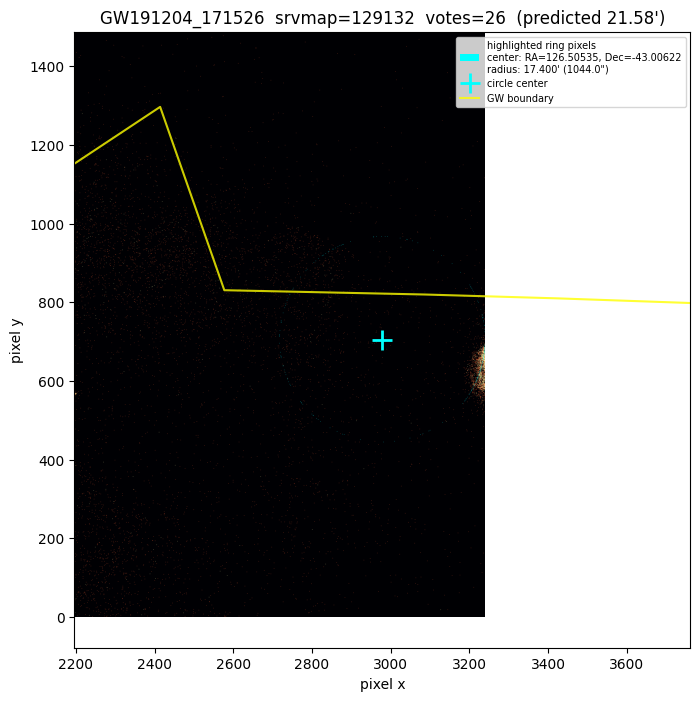

In [61]:
# blobs = load_boundary_polygon(boundary_path_for_event("GW190512_180714", BOUNDARY_DIR))
# plot_candidate(results["GW190512_180714"]["candidates"][0], "GW190512_180714", blobs, highlight_mode="recolor", save_dir="skytile analysis" )
# plot_top_candidates(results, "GW190512_180714", blobs, n=3, highlight_mode="recolor", save_dir="skytile analysis")

blobs = load_boundary_polygon(boundary_path_for_event("GW191204_171526", BOUNDARY_DIR))
plot_candidate(results["GW191204_171526"]["candidates"][14], "GW191204_171526", blobs, highlight_mode="recolor", save_dir="skytile analysis" )
# plot_top_candidates(results, "GW191204_171526", blobs, n=3, highlight_mode="recolor", save_dir="skytile analysis")


In [50]:
bad_files = check_all_skytiles(skytiles_root="skytiles")

[ok] GW190512_180714/srvmap_228099.fits.gz: ok
[ok] GW190512_180714/srvmap_230102.fits.gz: ok
[ok] GW190512_180714/srvmap_231099.fits.gz: ok
[ok] GW190512_180714/srvmap_232105.fits.gz: ok
[ok] GW190512_180714/srvmap_233102.fits.gz: ok
[ok] GW190512_180714/srvmap_235105.fits.gz: ok
[ok] GW190512_180714/srvmap_236102.fits.gz: ok
[ok] GW190512_180714/srvmap_237111.fits.gz: ok
[ok] GW190512_180714/srvmap_238105.fits.gz: ok
[ok] GW190512_180714/srvmap_239108.fits.gz: ok
[ok] GW190512_180714/srvmap_241111.fits.gz: ok
[ok] GW190512_180714/srvmap_242114.fits.gz: ok
[ok] GW190512_180714/srvmap_243108.fits.gz: ok
[ok] GW190512_180714/srvmap_244111.fits.gz: ok
[ok] GW190512_180714/srvmap_245114.fits.gz: ok
[ok] GW190512_180714/srvmap_245117.fits.gz: ok
[ok] GW190512_180714/srvmap_247111.fits.gz: ok
[ok] GW190512_180714/srvmap_248114.fits.gz: ok
[ok] GW190512_180714/srvmap_248117.fits.gz: ok
[ok] GW190512_180714/srvmap_249120.fits.gz: ok
[ok] GW190512_180714/srvmap_251114.fits.gz: ok
[ok] GW190512

In [ ]:
# See vote counts for the circles
for event_name, r in results.items():
    candidates = r["candidates"]
    if not candidates:
        print(f"{event_name}: no candidates")
        continue
    votes = sorted([c["votes"] for c in candidates], reverse=True)
    print(f"{event_name}: n={len(votes)}, top 10 votes = {votes[:10]}")

GW200208_130117: n=370, top 10 votes = [12, 12, 11, 11, 11, 11, 11, 11, 11, 11]
GW190828_065509: n=7077, top 10 votes = [16, 15, 15, 15, 14, 14, 14, 14, 14, 14]
GW190512_180714: n=3139, top 10 votes = [9, 8, 8, 8, 8, 8, 8, 8, 8, 8]
GW191215_223052: n=4793, top 10 votes = [9, 9, 9, 8, 8, 8, 8, 8, 8, 8]
GW190517_055101: n=3894, top 10 votes = [9, 9, 8, 8, 8, 8, 8, 8, 8, 8]
GW190828_063405: n=3598, top 10 votes = [8, 8, 8, 8, 8, 8, 8, 8, 8, 8]
GW191204_171526: n=2179, top 10 votes = [173, 163, 162, 160, 156, 154, 154, 153, 152, 152]


In [51]:
"""
Diagnostic: walks through run_halo_search's internal steps one at a
time for a single real tile from a zero-candidate event, printing
the size/count at each stage so we can see exactly where it bottoms
out to zero - an empty crop mask (tile doesn't actually overlap the
polygon), zero edge pixels (edge detector found nothing above
threshold), or zero CHT candidates despite real edges (radius window
mismatch or vote threshold too strict).
"""

def diagnose_event(event_name, dt_days, boundary_dir, skytiles_root="skytiles", max_tiles=3):
    """
    Runs the first max_tiles tiles for this event through each
    pipeline stage individually, printing sizes/counts at every step.
    """
    boundary_path = f"{boundary_dir}/{event_name}_boundary.json"
    tiles, samples, blobs = find_all_skytiles_for_event(boundary_path)
    print(f"Event {event_name}: {len(tiles)} tiles total, checking first {max_tiles}\n")

    theta_min, theta_max, theta_center = predicted_radius_window_arcmin(dt_days)
    print(f"theta window: [{theta_min:.2f}, {theta_max:.2f}] arcmin "
          f"-> pixel radii [{arcmin_to_pixels(theta_min):.0f}, {arcmin_to_pixels(theta_max):.0f}]\n")

    for tile in tiles[:max_tiles]:
        srvmap = tile["srvmap"]
        print(f"--- srvmap={srvmap} ---")

        try:
            image, wcs = load_local_skytile(event_name, srvmap, skytiles_root=skytiles_root)
        except Exception as e:
            print(f"  [FAILED TO LOAD]: {e}\n")
            continue

        print(f"  image shape: {image.shape}, dtype: {image.dtype}, "
              f"sum: {image.sum():.0f}, nonzero pixels: {(image > 0).sum()}")

        for blob_id, points in blobs.items():
            if len(points) < 3:
                continue
            poly_ra = [p[0] for p in points]
            poly_dec = [p[1] for p in points]

            cropped, mask = crop_to_polygon(image, wcs, poly_ra, poly_dec, margin_deg=0.5)
            n_mask_pixels = mask.sum()
            if n_mask_pixels == 0:
                print(f"  blob {blob_id}: mask is EMPTY (tile doesn't overlap this blob's polygon at all)")
                continue

            n_nonzero_in_mask = (cropped > 0).sum()
            print(f"  blob {blob_id}: mask covers {n_mask_pixels} px, "
                  f"{n_nonzero_in_mask} of those have a nonzero photon count")

            if n_mask_pixels < 100:
                print(f"    -> below min_mask_pixels=100, run_halo_search would bail out here")
                continue

            edges = simple_edge_map(cropped, threshold_sigma=2.5, ignore_mask=mask)
            print(f"    edge pixels found: {edges.sum()}")

            if edges.sum() == 0:
                print(f"    -> zero edges, CHT would find nothing")
                continue

            r_min_px = max(1, int(arcmin_to_pixels(theta_min)))
            r_max_px = int(arcmin_to_pixels(theta_max)) + 1
            candidates = circular_hough_transform(
                edges, range(r_min_px, r_max_px), vote_threshold_frac=0.6
            )
            print(f"    CHT candidates: {len(candidates)}")

        print()


In [52]:
diagnose_event("GW190512_180714", dt_days=214.78, boundary_dir=BOUNDARY_DIR)

Event GW190512_180714: 32 tiles total, checking first 3

theta window: [18.41, 27.62] arcmin -> pixel radii [276, 414]

--- srvmap=230102 ---
  image shape: (3240, 3240), dtype: >i4, sum: 75786, nonzero pixels: 75094
  blob 0: mask covers 5794413 px, 33686 of those have a nonzero photon count
    edge pixels found: 108
    CHT candidates: 51559
  blob 1: mask is EMPTY (tile doesn't overlap this blob's polygon at all)
  blob 2: mask is EMPTY (tile doesn't overlap this blob's polygon at all)
  blob 3: mask is EMPTY (tile doesn't overlap this blob's polygon at all)

--- srvmap=232105 ---
  image shape: (3240, 3240), dtype: >i4, sum: 72553, nonzero pixels: 71893
  blob 0: mask covers 4501420 px, 31222 of those have a nonzero photon count
    edge pixels found: 207
    CHT candidates: 205144
  blob 1: mask is EMPTY (tile doesn't overlap this blob's polygon at all)
  blob 2: mask is EMPTY (tile doesn't overlap this blob's polygon at all)
  blob 3: mask is EMPTY (tile doesn't overlap this blo

In [53]:
"""
Diagnostic: walks through run_halo_search's internal steps one at a
time for a single real tile from a zero-candidate event, printing
the size/count at each stage so we can see exactly where it bottoms
out to zero - an empty crop mask (tile doesn't actually overlap the
polygon), zero edge pixels (edge detector found nothing above
threshold), or zero CHT candidates despite real edges (radius window
mismatch or vote threshold too strict).
"""


def diagnose_event(event_name, dt_days, boundary_dir, skytiles_root="skytiles", max_tiles=3):
    """
    Runs the first max_tiles tiles for this event through each
    pipeline stage individually, printing sizes/counts at every step.
    """
    boundary_path = f"{boundary_dir}/{event_name}_boundary.json"
    tiles, samples, blobs = find_all_skytiles_for_event(boundary_path)
    print(f"Event {event_name}: {len(tiles)} tiles total, checking first {max_tiles}\n")

    theta_min, theta_max, theta_center = predicted_radius_window_arcmin(dt_days)
    print(f"theta window: [{theta_min:.2f}, {theta_max:.2f}] arcmin "
          f"-> pixel radii [{arcmin_to_pixels(theta_min):.0f}, {arcmin_to_pixels(theta_max):.0f}]\n")

    for tile in tiles[:max_tiles]:
        srvmap = tile["srvmap"]
        print(f"--- srvmap={srvmap} ---")

        try:
            image, wcs = load_local_skytile(event_name, srvmap, skytiles_root=skytiles_root)
        except Exception as e:
            print(f"  [FAILED TO LOAD]: {e}\n")
            continue

        print(f"  image shape: {image.shape}, dtype: {image.dtype}, "
              f"sum: {image.sum():.0f}, nonzero pixels: {(image > 0).sum()}")

        # WCS sanity check: print the tile's actual sky center per its
        # OWN header, vs what find_all_skytiles_for_event's API result
        # claimed the tile's center should be (tile["ra_cen"]/["de_cen"]).
        # A large mismatch here would mean either the wrong file got
        # loaded for this srvmap, or the WCS header itself is wrong/
        # not being read correctly.
        h, w = image.shape
        center_ra, center_dec = wcs.wcs_pix2world(w / 2, h / 2, 0)
        print(f"  WCS says tile center: RA={float(center_ra):.3f}, Dec={float(center_dec):.3f}")
        print(f"  API said tile center: RA={tile['ra_cen']:.3f}, Dec={tile['de_cen']:.3f}")
        print(f"  CRVAL from header: {wcs.wcs.crval}")

        for blob_id, points in blobs.items():
            if len(points) < 3:
                continue
            poly_ra = [p[0] for p in points]
            poly_dec = [p[1] for p in points]

            cropped, mask = crop_to_polygon(image, wcs, poly_ra, poly_dec, margin_deg=0.5)
            n_mask_pixels = mask.sum()
            if n_mask_pixels == 0:
                print(f"  blob {blob_id}: mask is EMPTY (tile doesn't overlap this blob's polygon at all)")
                continue

            n_nonzero_in_mask = (cropped > 0).sum()
            print(f"  blob {blob_id}: mask covers {n_mask_pixels} px, "
                  f"{n_nonzero_in_mask} of those have a nonzero photon count")

            if n_mask_pixels < 100:
                print(f"    -> below min_mask_pixels=100, run_halo_search would bail out here")
                continue

            edges = simple_edge_map(cropped, threshold_sigma=2.5, ignore_mask=mask)
            print(f"    edge pixels found: {edges.sum()}")

            if edges.sum() == 0:
                print(f"    -> zero edges, CHT would find nothing")
                continue

            r_min_px = max(1, int(arcmin_to_pixels(theta_min)))
            r_max_px = int(arcmin_to_pixels(theta_max)) + 1
            candidates = circular_hough_transform(
                edges, range(r_min_px, r_max_px), vote_threshold_frac=0.6
            )
            print(f"    CHT candidates: {len(candidates)}")

        print()


In [54]:
diagnose_event("GW190512_180714", dt_days=214.78, boundary_dir=BOUNDARY_DIR)


Event GW190512_180714: 32 tiles total, checking first 3

theta window: [18.41, 27.62] arcmin -> pixel radii [276, 414]

--- srvmap=230102 ---
  image shape: (3240, 3240), dtype: >i4, sum: 75786, nonzero pixels: 75094
  WCS says tile center: RA=230.338, Dec=-12.001
  API said tile center: RA=230.339, Dec=-12.002
  CRVAL from header: [230.338983 -12.002054]
  blob 0: mask covers 5794413 px, 33686 of those have a nonzero photon count
    edge pixels found: 108
    CHT candidates: 51559
  blob 1: mask is EMPTY (tile doesn't overlap this blob's polygon at all)
  blob 2: mask is EMPTY (tile doesn't overlap this blob's polygon at all)
  blob 3: mask is EMPTY (tile doesn't overlap this blob's polygon at all)

--- srvmap=232105 ---
  image shape: (3240, 3240), dtype: >i4, sum: 72553, nonzero pixels: 71893
  WCS says tile center: RA=232.307, Dec=-15.002
  API said tile center: RA=232.308, Dec=-15.003
  CRVAL from header: [232.307692 -15.002564]
  blob 0: mask covers 4501420 px, 31222 of those ha

In [55]:
from astropy.io import fits

with fits.open("skytiles/SKYMAPS_052022_MPE.fits") as hdul:
    hdul.info()
    print(hdul[1].columns)
    print(hdul[1].data[:5])

Filename: skytiles/SKYMAPS_052022_MPE.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      16   (2733,)   uint8   
  1  SMAPS         1 BinTableHDU     72   2447R x 24C   [J, I, D, D, D, D, D, D, D, D, D, D, D, D, I, J, J, J, J, J, J, J, J, J]   
ColDefs(
    name = 'SRVMAP'; format = 'J'
    name = 'OWNER'; format = 'I'
    name = 'RA_MIN'; format = 'D'; unit = 'deg'
    name = 'RA_MAX'; format = 'D'; unit = 'deg'
    name = 'DE_MIN'; format = 'D'; unit = 'deg'
    name = 'DE_MAX'; format = 'D'; unit = 'deg'
    name = 'RA_CEN'; format = 'D'; unit = 'deg'
    name = 'DE_CEN'; format = 'D'; unit = 'deg'
    name = 'ELON_CEN'; format = 'D'; unit = 'deg'
    name = 'ELAT_CEN'; format = 'D'; unit = 'deg'
    name = 'GLON_CEN'; format = 'D'; unit = 'deg'
    name = 'GLAT_CEN'; format = 'D'; unit = 'deg'
    name = 'X_MIN'; format = 'D'; unit = 'arcmin'
    name = 'Y_MIN'; format = 'D'; unit = 'arcmin'
    name = 'N_NBRS'; format = 'I'
    

In [56]:
from astropy.io import fits
import numpy as np

with fits.open("skytiles/SKYMAPS_052022_MPE.fits") as hdul:
    data = hdul[1].data
    srvmaps = np.array(data["SRVMAP"])
    
    match = srvmaps == 136123
    print("136123 exists in table:", match.any())
    
    if match.any():
        idx = np.where(match)[0][0]
        print("RA_CEN:", data["RA_CEN"][idx])
        print("DE_CEN:", data["DE_CEN"][idx])
    else:
        # find the closest real srvmap values numerically, for context
        closest = srvmaps[np.argsort(np.abs(srvmaps - 136123))[:5]]
        print("closest real srvmap values in the table:", closest)

136123 exists in table: True
RA_CEN: 135.88235294117646
DE_CEN: -33.00610168997309
